In [2]:
import numpy as np
import matplotlib.pyplot as plt
from hospital_models import simulate_hospital_model, simulate_age_structured_model
from plotting_utils import plot_hospital_simulation_stats, plot_age_structured_results

## **Hospital Overflow + Unmet Care Simulation and Analysis**

This is essentially just a crude model with some simulations and subsequent analysis of hospital overflow and unmet care needs over a specified period. It models patient arrivals, hospital capacity, and the resulting overflow and unmet care statistics, we can modify this in many ways if we want.

- I kind of need to triple check but I feel like this covers most of the things that Dr. Larremore was saying in his feedback.

- The implementation sets up a SIXHRD compartmental model with hospital capacity contraints.

- It uses Euler's method to simulate the system with a time step of ```dt``` over a period of ```Tmax``` days.

- It implements the smooth Hill function for modeling hospital admission gating.

- It tracks key metrics such as total overflow and unmet care needs.

- It includes vaccine effects using a leaky model when coverage $\gt 0$.
- It visualizes the results of the epidemic dynamics, hospital capacity utilization, overflow, and summary statistics.

## **The breakdown:**

- **S**: Susceptible
- **I**: Infected, "uncomplicated cases" (mild or early in disease perhaps)
- **X**: Severe cases who NEED to go to the hospital for care
- **H**: Hospitalized (subset of X who successfully get admitted)
- **R**: Recovered
- **D**: Dead

**Key parameters**:
- `beta`: Transmission rate
- `theta_X`, `theta_H`: Relative infectiousness of X and H compartments vs I
- `sigma`: Rate that I people move into X (severe cases)
- `gamma_I`,`gamma_X`, `gamma_H`: Recovery rates for I, X, and H compartments
- `mu_I`,`mu_X`, `mu_H`: Mortality rates for I, X, and H compartments
- `hosp_capacity = K`: Maximum hospital capacity (number of beds)
- `hill_coef = n`: How sharply the hospital admissions are throttled as H approaches K
- `coverage`, `VE`: Vaccine coverage and vaccine efficacy (leaky model)

## **Force of Infection**

$$\lambda = \beta_{eff} \frac{I + \theta_X X + \theta_H H}{N}$$

Where $\beta_{eff} = \beta (1 - coverage * VE)$

and new infections `new_inf` = $\lambda * S$

So the vaccine acts on $\beta$ and doesn't block infection completely.

## **Hospital capacity gate**

This implementation is using a smooth "Hill function" to model gating of hospital admissions:

$$g(H) = \frac{1}{1 + (\frac{H}{K})^n}$$

then

$$admissions = \sigma * X * g(H)$$

- When $H \ll K, g \approx 1$: almost everyone in X who should be admitted is admitted.
- When $H \gg K, g \rightarrow 0$: very few admissions occur as the hospital is at or beyond capacity. Unmet need is driven upwards.
- At $H = K, g = \frac{1}{2}$: admissions are cut in half when hospital is at capacity.

This is a soft capacity constraint, meaning that admissions don't just stop when capacity is reached, but are slowed down smoothly and with more realism.

## **The ODEs:**


\begin{aligned}
\frac{dS}{dt} &= -\text{new\_inf} \\
\frac{dI}{dt} &= \text{new\_inf} - (\gamma_I + \mu_I + \sigma) I \\
\frac{dX}{dt} &= \sigma I - (\gamma_X + \mu_X) X - \text{admit} \\
\frac{dH}{dt} &= \text{admit} - (\gamma_H + \mu_H) H \\
\frac{dR}{dt} &= \gamma_I I + \gamma_X X + \gamma_H H \\
\frac{dD}{dt} &= \mu_I I + \mu_X X + \mu_H H
\end{aligned}

- So people leave $I$ either by recovering, dying, or progressing into severe cases $X$.
- People in $X$ can either recover, die, or get admitted to the hospital $H$ (if capacity allows).
- People in $H$ can recover or die.
- $R$ and $D$ collect all the outflows from the other compartments.


## **Metrics being tracked in the model:**

- `overflow = max(0, H - K)`: This is how many patients are in the hospital beyond capacity at each time step.
- `cumulative_overflow`: Total burden of overflow on the system over a single simulation run.
- `unmet_care = eta * X - admit`: People in X who need care but aren't because of capacity limits.
- `cumulative_unmet`: Total unmet care needs over the simulation period. 

# Here we simulate over values of Beta and observe hospital overflow and unmet care needs.

In [3]:
peak_occupancies = []
cumulative_overflows = []
final_death_counts = []
beta_vals = [0.1,0.125,0.15,0.175,0.2,0.225,0.25,0.275,0.3, 0.325,0.35,0.375,0.4,0.425,0.45,0.475,0.5,0.525, 0.55,0.575, 0.6,0.625, 0.65,0.675, 0.7,0.725,0.75,0.775,0.8,0.825,0.85,0.875,0.9]

for beta in beta_vals:
    times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, unmet_care = simulate_hospital_model(
        beta=beta,
        sigma=0.2,
        eta=0.3,
        gamma_I=0.1,
        mu_I=0.01,
        gamma_X=0.15,
        mu_X=0.05,
        gamma_H=0.2,
        mu_H=0.02,
        theta_X=0.5,
        theta_H=0.3,
        hosp_capacity=100,
        hill_coef=4,
        coverage=0.1,
        VE=0.7,
        N=10000,
        S=None,
        I=None,
        X=None,
        H=None,
        R=None,
        D=None,
        Tmax=200,
        time_step=0.1
    )
    
    peak_occupancies.append(max(H_vals))
    final_death_counts.append(D_vals[-1])
    cumulative_overflows.append(cumulative_overflow) 
    
    # plot_hospital_simulation_stats(times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, hosp_capacity=100, N = 10000)
    
    
    print(f"\nBeta: {beta}")
    print(f"Total deaths: {D_vals[-1]:.0f}")
    print(f"Peak hospital occupancy: {max(H_vals):.1f} (Capacity: 100)")
    print(f"Cumulative overflow: {cumulative_overflow:.1f} patient-days")


Beta: 0.1
Total deaths: 2
Peak hospital occupancy: 1.9 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.125
Total deaths: 3
Peak hospital occupancy: 2.1 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.15
Total deaths: 3
Peak hospital occupancy: 2.3 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.175
Total deaths: 5
Peak hospital occupancy: 2.5 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.2
Total deaths: 7
Peak hospital occupancy: 2.8 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.225
Total deaths: 15
Peak hospital occupancy: 3.3 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.25
Total deaths: 67
Peak hospital occupancy: 5.0 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.275
Total deaths: 270
Peak hospital occupancy: 29.7 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.3
Total deaths: 478
Peak hospital occupancy: 71.9 (Capacity: 100)
Cumulative overflow: 0.0 patie

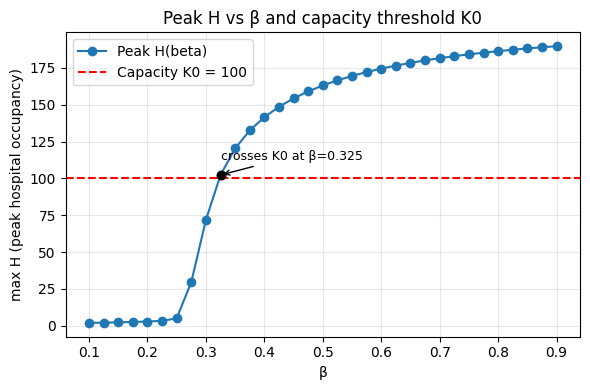

In [4]:
K0 = 100  # capacity threshold

plt.figure(figsize=(6, 4))
plt.plot(beta_vals, peak_occupancies, marker='o', label='Peak H(beta)')
plt.axhline(K0, color='red', linestyle='--', label=f'Capacity K0 = {K0}')

# find first beta where peak H crosses K0
cross_beta = None
for b, h in zip(beta_vals, peak_occupancies):
    if h >= K0:
        cross_beta = b
        break

if cross_beta is not None:
    # mark the crossing point
    cross_H = peak_occupancies[beta_vals.index(cross_beta)]
    plt.scatter([cross_beta], [cross_H], color='black', zorder=5)
    plt.annotate(f'crosses K0 at β={cross_beta}',
                 xy=(cross_beta, cross_H),
                 xytext=(cross_beta, cross_H * 1.1),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

plt.xlabel('β')
plt.ylabel('max H (peak hospital occupancy)')
plt.title('Peak H vs β and capacity threshold K0')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# How does hospital capacity $K$ affect deaths and overflow for a given $\beta$?

- Fixing all other parameters and $\beta$,
- Sweeping over `hosp_capacity` values
- For each K, simulate and record:
    - Total deaths at end of simulation
    - Cumulative overflow
    - Cumulative unmet care needs


Hospital Capacity: 25
Total deaths: 1554
Peak hospital occupancy: 56.4 (Capacity: 25)
Cumulative overflow: 947.1 patient-days

Hospital Capacity: 50
Total deaths: 1495
Peak hospital occupancy: 96.5 (Capacity: 50)
Cumulative overflow: 1210.8 patient-days

Hospital Capacity: 75
Total deaths: 1448
Peak hospital occupancy: 131.5 (Capacity: 75)
Cumulative overflow: 1314.7 patient-days

Hospital Capacity: 100
Total deaths: 1409
Peak hospital occupancy: 163.1 (Capacity: 100)
Cumulative overflow: 1333.4 patient-days

Hospital Capacity: 125
Total deaths: 1375
Peak hospital occupancy: 192.2 (Capacity: 125)
Cumulative overflow: 1298.9 patient-days

Hospital Capacity: 150
Total deaths: 1345
Peak hospital occupancy: 219.2 (Capacity: 150)
Cumulative overflow: 1228.3 patient-days

Hospital Capacity: 175
Total deaths: 1319
Peak hospital occupancy: 244.4 (Capacity: 175)
Cumulative overflow: 1133.0 patient-days

Hospital Capacity: 200
Total deaths: 1295
Peak hospital occupancy: 268.1 (Capacity: 200)
Cu

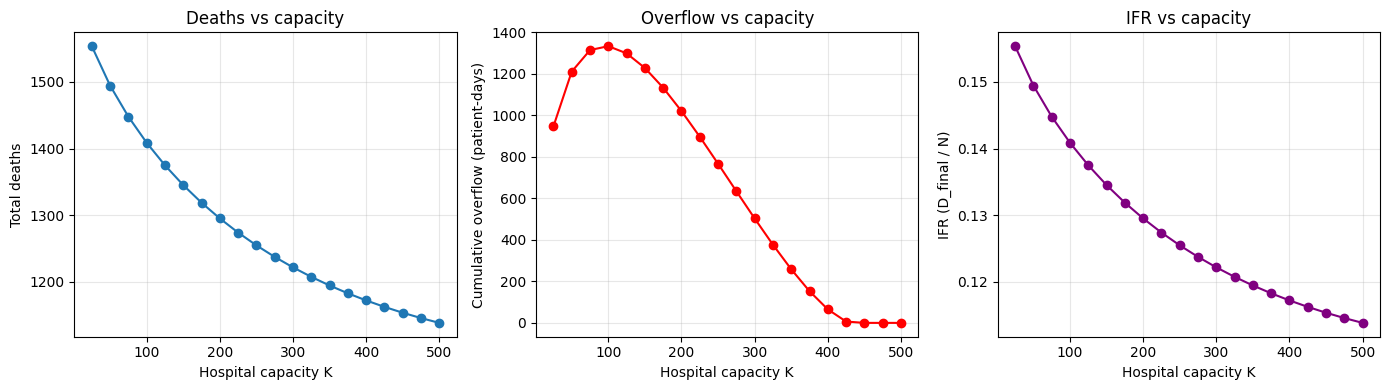

In [5]:
K_vals = [25, 50, 75, 100,125, 150, 175, 200,225, 250, 275, 300, 325, 350,375, 400,425, 450, 475, 500]

deaths_vs_K = []
overflow_vs_K = []
ifr_vs_K = []

for K in K_vals:
    times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, unmet_care = simulate_hospital_model(
        beta=0.5,
        sigma=0.2,
        eta=0.3,
        gamma_I=0.1,
        mu_I=0.01,
        gamma_X=0.15,
        mu_X=0.05,
        gamma_H=0.2,
        mu_H=0.02,
        theta_X=0.5,
        theta_H=0.3,
        hosp_capacity=K,
        hill_coef=4,
        coverage=0.1,
        VE=0.7,
        N=10000,
        S=None,
        I=None,
        X=None,
        H=None,
        R=None,
        D=None,
        Tmax=200,
        time_step=0.1
    )
    
    final_deaths = D_vals[-1]
    deaths_vs_K.append(final_deaths)
    overflow_vs_K.append(cumulative_overflow)
    ifr_vs_K.append(final_deaths / 10000)  # IFR = D_final / N
    
    # plot_hospital_simulation_stats(times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, hosp_capacity=100, N = 10000)
    
    print(f"\nHospital Capacity: {K}")
    print(f"Total deaths: {D_vals[-1]:.0f}")
    print(f"Peak hospital occupancy: {max(H_vals):.1f} (Capacity: {K})")
    print(f"Cumulative overflow: {cumulative_overflow:.1f} patient-days")
    
    # Now plot how outcomes change with capacity
plt.figure(figsize=(14, 4))

# Deaths vs capacity
plt.subplot(1, 3, 1)
plt.plot(K_vals, deaths_vs_K, marker='o')
plt.xlabel('Hospital capacity K')
plt.ylabel('Total deaths')
plt.title('Deaths vs capacity')
plt.grid(True, alpha=0.3)

# Cumulative overflow vs capacity
plt.subplot(1, 3, 2)
plt.plot(K_vals, overflow_vs_K, marker='o', color='red')
plt.xlabel('Hospital capacity K')
plt.ylabel('Cumulative overflow (patient-days)')
plt.title('Overflow vs capacity')
plt.grid(True, alpha=0.3)

# IFR vs capacity
plt.subplot(1, 3, 3)
plt.plot(K_vals, ifr_vs_K, marker='o', color='purple')
plt.xlabel('Hospital capacity K')
plt.ylabel('IFR (D_final / N)')
plt.title('IFR vs capacity')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## **Vaccine vs Beds Tradeoff Analysis**

In [6]:
# 10000 data points (100x100), can be adjusted to get a higher resolution image
resolution_vax = 100
resolution_beds = 100

coverage_levels = np.linspace(0, 1, resolution_vax)
hosp_capacities = np.linspace(0, 1000, resolution_beds)

# matrix to store final deaths
deaths_grid = np.zeros((len(coverage_levels), len(hosp_capacities)))

print(f"Running simulation sweep ({resolution_vax}x{resolution_beds} grid)...")

for i, coverage in enumerate(coverage_levels):
    for j, K in enumerate(hosp_capacities):
        _, _, _, _, _, _, D_vals, _, _, _, _ = simulate_hospital_model(
            beta=0.5,
            sigma=0.2,
            eta=0.3,
            gamma_I=0.1,
            mu_I=0.01,
            gamma_X=0.15,
            mu_X=0.05,
            gamma_H=0.2,
            mu_H=0.02,
            theta_X=0.5,
            theta_H=0.3,
            hosp_capacity=K,
            hill_coef=4,
            coverage=coverage,
            VE=0.7,
            N=100000,
            Tmax=200,
            time_step=0.1
        )
        deaths_grid[i, j] = D_vals[-1]

print("Simulation complete.")

Running simulation sweep (100x100 grid)...
Simulation complete.
Simulation complete.


## **Heatmap of total deaths as a function of hospital capacity (beds) and vaccine coverage with contour lines for iso-death levels**:

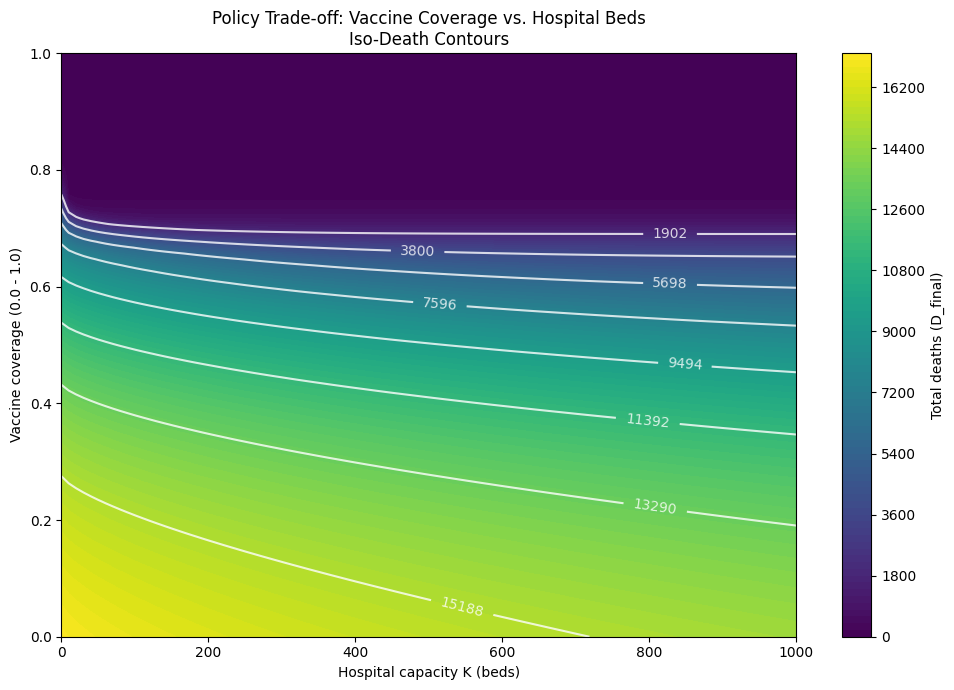

In [7]:
# mesh grid for contour plotting
K_grid, C_grid = np.meshgrid(hosp_capacities, coverage_levels)

plt.figure(figsize=(10, 7))

# filled contour plot for deaths
fill = plt.contourf(
    K_grid, C_grid, deaths_grid,
    levels=100,
    cmap='viridis'
)
cbar = plt.colorbar(fill)
cbar.set_label('Total deaths (D_final)')

# this is selecting specific levels for the contour labels that represent distinct policy thresholds at which deaths change significantly
iso_levels = np.linspace(deaths_grid.min(), deaths_grid.max(), 10)
cs = plt.contour(
    K_grid, C_grid, deaths_grid,
    levels=iso_levels,
    colors='white',
    linewidths=1.5,
    alpha=0.8
)

# label the contours)
plt.clabel(cs, inline=True, fontsize=10)

plt.xlabel('Hospital capacity K (beds)')
plt.ylabel('Vaccine coverage (0.0 - 1.0)')
plt.title('Policy Trade-off: Vaccine Coverage vs. Hospital Beds\nIso-Death Contours')
plt.tight_layout()
plt.show()

# Age-Structured SIXHRD Model

## Model Extension with Age Groups

We now extend the SIXHRD model to include age structure. The population is divided into age groups (e.g., young, middle, elderly), each with:

- **Age-specific parameters**:
  - `sigma_a`: Progression rate to severe cases for age group a
  - `mu_I_a, mu_X_a, mu_H_a`: Age-specific mortality rates
  - `eta_a`: Age-specific hospitalization need rate
  
- **Contact matrix** `C[a,b]`: Rate at which age group a contacts age group b
  
- **Force of infection** for age group a:
$$\lambda_a = \beta_{eff} \sum_b C_{ab} \frac{I_b + \theta_X X_b + \theta_H H_b}{N_b}$$

The hospital capacity constraint is **shared** across all age groups, meaning total hospitalized H_total = ∑H_a must respect the capacity K.

## Example: 3 Age Groups with Realistic Parameters

We'll simulate with three age groups:
- **Young** (0-19 years): Low severity, low mortality
- **Middle** (20-64 years): Moderate severity and mortality  
- **Elderly** (65+ years): High severity, high mortality

The contact matrix represents mixing patterns (e.g., young people contact each other more, elderly have lower contact rates).

In [8]:
# Define age-specific parameters
# Young (0-19): low severity, low mortality
young_params = {
    'sigma': 0.1,      # Lower progression to severe
    'eta': 0.2,        # Lower hospitalization rate
    'gamma_I': 0.12,
    'mu_I': 0.001,     # Very low mortality in I
    'gamma_X': 0.18,
    'mu_X': 0.01,      # Low mortality in X
    'gamma_H': 0.25,
    'mu_H': 0.005      # Low mortality in H
}

# Middle (20-64): moderate severity and mortality
middle_params = {
    'sigma': 0.2,
    'eta': 0.3,
    'gamma_I': 0.1,
    'mu_I': 0.01,
    'gamma_X': 0.15,
    'mu_X': 0.05,
    'gamma_H': 0.2,
    'mu_H': 0.02
}

# Elderly (65+): high severity, high mortality
elderly_params = {
    'sigma': 0.3,      # Higher progression to severe
    'eta': 0.5,        # Higher hospitalization rate
    'gamma_I': 0.08,
    'mu_I': 0.03,      # Higher mortality in I
    'gamma_X': 0.12,
    'mu_X': 0.15,      # Much higher mortality in X
    'gamma_H': 0.15,
    'mu_H': 0.08       # Much higher mortality in H
}

age_params = [young_params, middle_params, elderly_params]

# Contact matrix (simplified - young mix more with young, etc.)
# Rows = infector age, Cols = infectee age
contact_matrix = np.array([
    [10.0, 3.0, 1.0],   # Young contacts: mostly young
    [3.0, 8.0, 2.0],    # Middle contacts: mostly middle
    [1.0, 2.0, 4.0]     # Elderly contacts: lower overall
])

# Population sizes
age_pops = [3000, 5000, 2000]  # Young, Middle, Elderly (total 10,000)

print("Age-structured model parameters:")
print(f"Population: Young={age_pops[0]}, Middle={age_pops[1]}, Elderly={age_pops[2]}")
print(f"\nContact matrix:\n{contact_matrix}")
print("\nAge-specific severity (sigma): Young={:.2f}, Middle={:.2f}, Elderly={:.2f}".format(
    young_params['sigma'], middle_params['sigma'], elderly_params['sigma']))
print("Age-specific hospitalization (eta): Young={:.2f}, Middle={:.2f}, Elderly={:.2f}".format(
    young_params['eta'], middle_params['eta'], elderly_params['eta']))

Age-structured model parameters:
Population: Young=3000, Middle=5000, Elderly=2000

Contact matrix:
[[10.  3.  1.]
 [ 3.  8.  2.]
 [ 1.  2.  4.]]

Age-specific severity (sigma): Young=0.10, Middle=0.20, Elderly=0.30
Age-specific hospitalization (eta): Young=0.20, Middle=0.30, Elderly=0.50


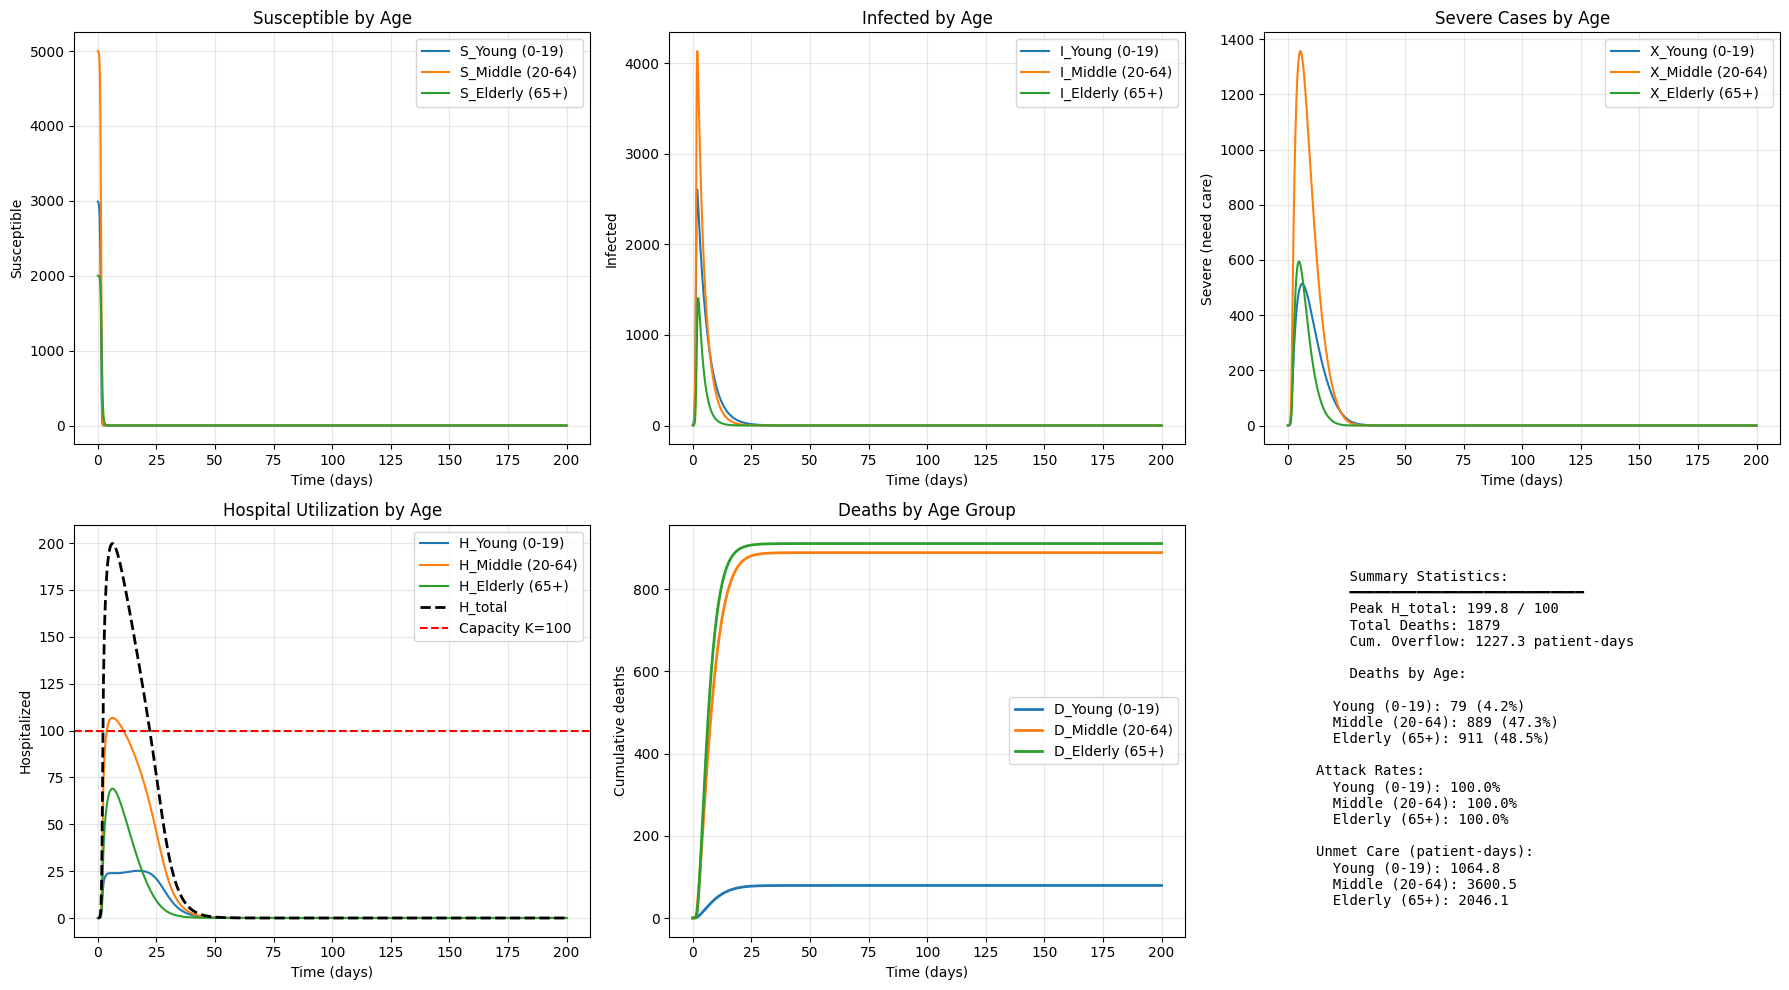


Age-Structured Model Results
Total deaths: 1879
Peak hospital occupancy: 199.8 (Capacity: 100)
Cumulative overflow: 1227.3 patient-days
  Young (0-19): 79 deaths, AR=100.0%
  Middle (20-64): 889 deaths, AR=100.0%
  Elderly (65+): 911 deaths, AR=100.0%


In [9]:
# Run age-structured simulation
results = simulate_age_structured_model(
    beta=0.5,
    age_params=age_params,
    contact_matrix=contact_matrix,
    hosp_capacity=100,
    hill_coef=4,
    coverage=0.1,  # Uniform coverage
    VE=0.7,
    age_pops=age_pops,
    theta_X=0.5,
    theta_H=0.3,
    Tmax=200,
    time_step=0.1
)

plot_age_structured_results(results, hosp_capacity=100, 
                           age_labels=['Young (0-19)', 'Middle (20-64)', 'Elderly (65+)'])

## Age-Targeted Vaccination Strategy

Now we can explore **age-targeted vaccination** - what if we prioritize elderly vs. uniform coverage?

In [10]:
# Compare different vaccination strategies
strategies = {
    'No vaccination': [0.0, 0.0, 0.0],
    'Uniform 30%': [0.3, 0.3, 0.3],
    'Elderly priority': [0.1, 0.2, 0.7],
    'Young priority': [0.7, 0.2, 0.1],
    'Middle priority': [0.1, 0.7, 0.2]
}

strategy_results = {}

for strategy_name, coverage_by_age in strategies.items():
    results = simulate_age_structured_model(
        beta=0.5,
        age_params=age_params,
        contact_matrix=contact_matrix,
        hosp_capacity=100,
        hill_coef=4,
        coverage=coverage_by_age,
        VE=0.7,
        age_pops=age_pops,
        theta_X=0.5,
        theta_H=0.3,
        Tmax=200,
        time_step=0.1
    )
    
    total_deaths = sum([results['D'][a][-1] for a in range(3)])
    peak_H = max(results['H_total'])
    
    strategy_results[strategy_name] = {
        'total_deaths': total_deaths,
        'deaths_by_age': [results['D'][a][-1] for a in range(3)],
        'peak_H': peak_H,
        'cum_overflow': results['cum_overflow'],
        'coverage': coverage_by_age
    }
    
    print(f"\n{strategy_name}:")
    print(f"  Coverage: Young={coverage_by_age[0]:.1f}, Middle={coverage_by_age[1]:.1f}, Elderly={coverage_by_age[2]:.1f}")
    print(f"  Total deaths: {total_deaths:.0f}")
    print(f"  Deaths by age: Young={results['D'][0][-1]:.0f}, Middle={results['D'][1][-1]:.0f}, Elderly={results['D'][2][-1]:.0f}")
    print(f"  Peak hospital: {peak_H:.1f}")
    print(f"  Cumulative overflow: {results['cum_overflow']:.1f}")


No vaccination:
  Coverage: Young=0.0, Middle=0.0, Elderly=0.0
  Total deaths: 1879
  Deaths by age: Young=79, Middle=889, Elderly=911
  Peak hospital: 199.8
  Cumulative overflow: 1227.1

Uniform 30%:
  Coverage: Young=0.3, Middle=0.3, Elderly=0.3
  Total deaths: 1879
  Deaths by age: Young=79, Middle=889, Elderly=911
  Peak hospital: 199.7
  Cumulative overflow: 1227.7

Elderly priority:
  Coverage: Young=0.1, Middle=0.2, Elderly=0.7
  Total deaths: 1879
  Deaths by age: Young=79, Middle=888, Elderly=913
  Peak hospital: 199.5
  Cumulative overflow: 1229.6

Young priority:
  Coverage: Young=0.7, Middle=0.2, Elderly=0.1
  Total deaths: 1878
  Deaths by age: Young=79, Middle=888, Elderly=910
  Peak hospital: 199.6
  Cumulative overflow: 1229.2

Middle priority:
  Coverage: Young=0.1, Middle=0.7, Elderly=0.2
  Total deaths: 1879
  Deaths by age: Young=79, Middle=890, Elderly=910
  Peak hospital: 199.4
  Cumulative overflow: 1228.0


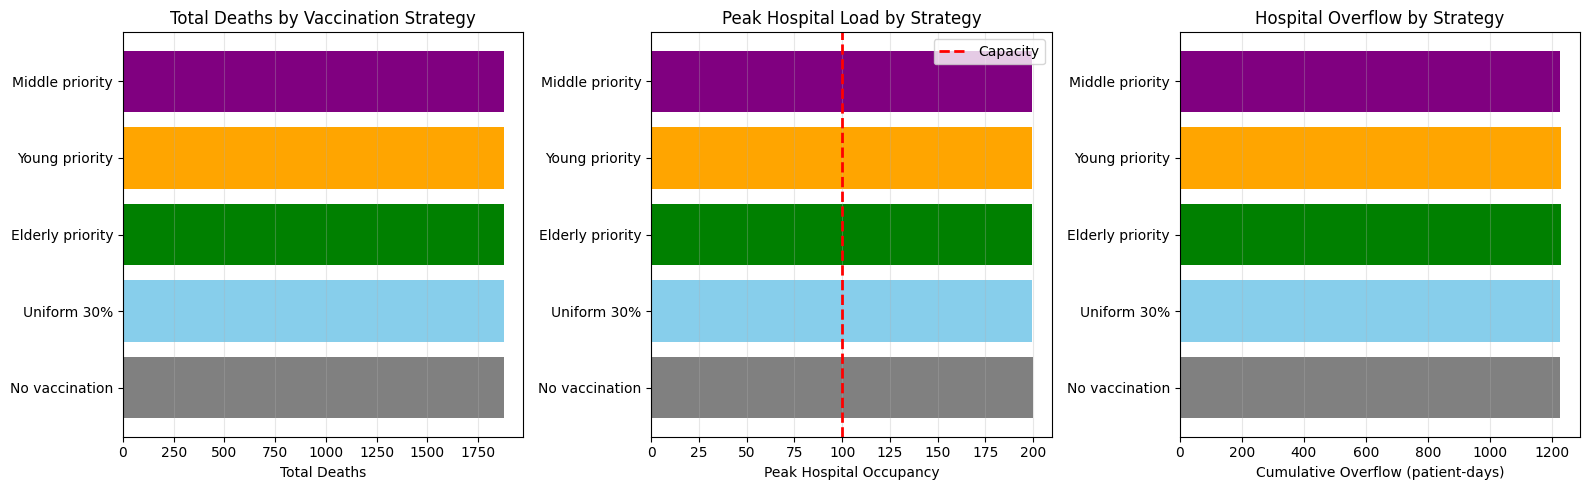

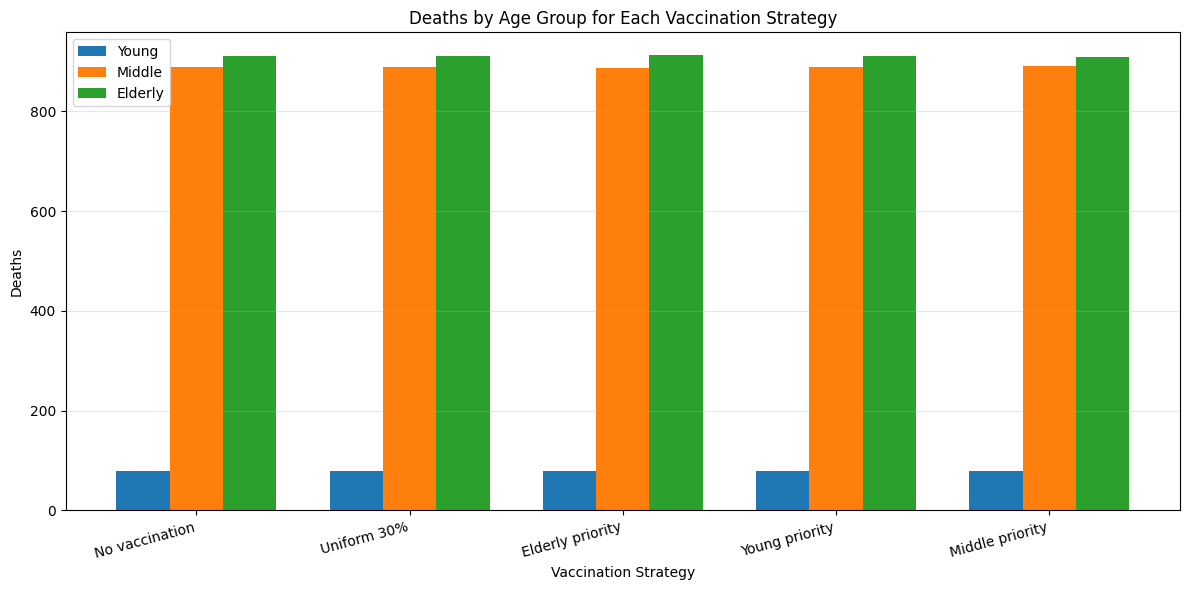

In [11]:
# Visualize vaccination strategy comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

strategies_list = list(strategy_results.keys())
total_deaths_list = [strategy_results[s]['total_deaths'] for s in strategies_list]
peak_H_list = [strategy_results[s]['peak_H'] for s in strategies_list]
overflow_list = [strategy_results[s]['cum_overflow'] for s in strategies_list]

# Total deaths comparison
axes[0].barh(strategies_list, total_deaths_list, color=['gray', 'skyblue', 'green', 'orange', 'purple'])
axes[0].set_xlabel('Total Deaths')
axes[0].set_title('Total Deaths by Vaccination Strategy')
axes[0].grid(True, alpha=0.3, axis='x')

# Peak hospital occupancy
axes[1].barh(strategies_list, peak_H_list, color=['gray', 'skyblue', 'green', 'orange', 'purple'])
axes[1].axvline(x=100, color='red', linestyle='--', label='Capacity', linewidth=2)
axes[1].set_xlabel('Peak Hospital Occupancy')
axes[1].set_title('Peak Hospital Load by Strategy')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Cumulative overflow
axes[2].barh(strategies_list, overflow_list, color=['gray', 'skyblue', 'green', 'orange', 'purple'])
axes[2].set_xlabel('Cumulative Overflow (patient-days)')
axes[2].set_title('Hospital Overflow by Strategy')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Deaths by age group for each strategy
fig, ax = plt.subplots(figsize=(12, 6))
age_labels = ['Young', 'Middle', 'Elderly']
x = np.arange(len(strategies_list))
width = 0.25

for i, age in enumerate(age_labels):
    deaths = [strategy_results[s]['deaths_by_age'][i] for s in strategies_list]
    ax.bar(x + i*width, deaths, width, label=age)

ax.set_xlabel('Vaccination Strategy')
ax.set_ylabel('Deaths')
ax.set_title('Deaths by Age Group for Each Vaccination Strategy')
ax.set_xticks(x + width)
ax.set_xticklabels(strategies_list, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Optimal Vaccine Allocation Across Age Groups

Let's find the optimal allocation of a **fixed total vaccine supply** across age groups to minimize total deaths.

In [12]:
# Grid search over allocation strategies with fixed total coverage
# Total vaccine doses = 30% of total population
# Explore how to allocate across age groups

total_coverage_target = 0.3  # 30% of total pop
total_pop = sum(age_pops)
total_doses = total_coverage_target * total_pop

# Generate allocation grid
# coverage_young = fraction of young vaccinated (0 to 1)
# coverage_middle = fraction of middle vaccinated (0 to 1)  
# coverage_elderly = determined by constraint

n_grid = 20
young_cov_range = np.linspace(0, 1, n_grid)
middle_cov_range = np.linspace(0, 1, n_grid)

deaths_allocation_grid = np.zeros((n_grid, n_grid))
overflow_allocation_grid = np.zeros((n_grid, n_grid))

print(f"Searching for optimal allocation of {total_doses:.0f} vaccine doses...")
print(f"(Equivalent to {total_coverage_target*100:.0f}% of total population)")

for i, cov_young in enumerate(young_cov_range):
    for j, cov_middle in enumerate(middle_cov_range):
        # Calculate elderly coverage from constraint
        doses_young = cov_young * age_pops[0]
        doses_middle = cov_middle * age_pops[1]
        doses_elderly = total_doses - doses_young - doses_middle
        
        # Check if feasible
        if doses_elderly < 0 or doses_elderly > age_pops[2]:
            deaths_allocation_grid[i, j] = np.nan
            overflow_allocation_grid[i, j] = np.nan
            continue
        
        cov_elderly = doses_elderly / age_pops[2]
        
        # Run simulation
        results = simulate_age_structured_model(
            beta=0.5,
            age_params=age_params,
            contact_matrix=contact_matrix,
            hosp_capacity=100,
            hill_coef=4,
            coverage=[cov_young, cov_middle, cov_elderly],
            VE=0.7,
            age_pops=age_pops,
            theta_X=0.5,
            theta_H=0.3,
            Tmax=200,
            time_step=0.1
        )
        
        total_deaths = sum([results['D'][a][-1] for a in range(3)])
        deaths_allocation_grid[i, j] = total_deaths
        overflow_allocation_grid[i, j] = results['cum_overflow']

print("Search complete.")

Searching for optimal allocation of 3000 vaccine doses...
(Equivalent to 30% of total population)
Search complete.
Search complete.


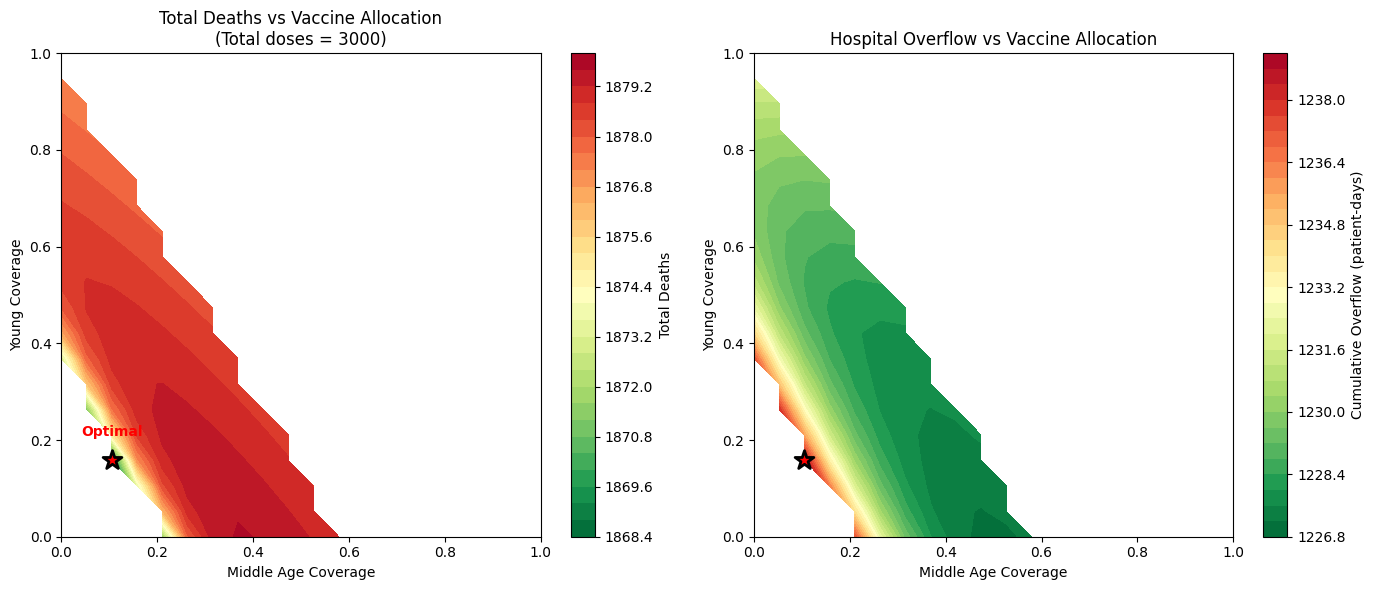


OPTIMAL ALLOCATION (Fixed total: 30% of population)
Young coverage: 15.8%
Middle coverage: 10.5%
Elderly coverage: 100.0%

Minimum deaths: 1869
Overflow at optimum: 1238.9 patient-days


In [13]:
# Visualize optimal allocation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Deaths heatmap
im1 = axes[0].contourf(middle_cov_range, young_cov_range, deaths_allocation_grid, 
                       levels=30, cmap='RdYlGn_r')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Total Deaths')

# Find and mark minimum
min_idx = np.nanargmin(deaths_allocation_grid)
min_i, min_j = np.unravel_index(min_idx, deaths_allocation_grid.shape)
opt_young = young_cov_range[min_i]
opt_middle = middle_cov_range[min_j]
opt_elderly = (total_doses - opt_young*age_pops[0] - opt_middle*age_pops[1]) / age_pops[2]

axes[0].scatter(opt_middle, opt_young, color='red', s=200, marker='*', 
               edgecolors='black', linewidths=2, zorder=10)
axes[0].text(opt_middle, opt_young + 0.05, 'Optimal', 
            ha='center', fontsize=10, weight='bold', color='red')

axes[0].set_xlabel('Middle Age Coverage')
axes[0].set_ylabel('Young Coverage')
axes[0].set_title(f'Total Deaths vs Vaccine Allocation\n(Total doses = {total_doses:.0f})')

# Overflow heatmap
im2 = axes[1].contourf(middle_cov_range, young_cov_range, overflow_allocation_grid, 
                       levels=30, cmap='RdYlGn_r')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Cumulative Overflow (patient-days)')

axes[1].scatter(opt_middle, opt_young, color='red', s=200, marker='*', 
               edgecolors='black', linewidths=2, zorder=10)
axes[1].set_xlabel('Middle Age Coverage')
axes[1].set_ylabel('Young Coverage')
axes[1].set_title('Hospital Overflow vs Vaccine Allocation')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"OPTIMAL ALLOCATION (Fixed total: {total_coverage_target*100:.0f}% of population)")
print(f"{'='*60}")
print(f"Young coverage: {opt_young*100:.1f}%")
print(f"Middle coverage: {opt_middle*100:.1f}%")
print(f"Elderly coverage: {opt_elderly*100:.1f}%")
print(f"\nMinimum deaths: {np.nanmin(deaths_allocation_grid):.0f}")
print(f"Overflow at optimum: {overflow_allocation_grid[min_i, min_j]:.1f} patient-days")

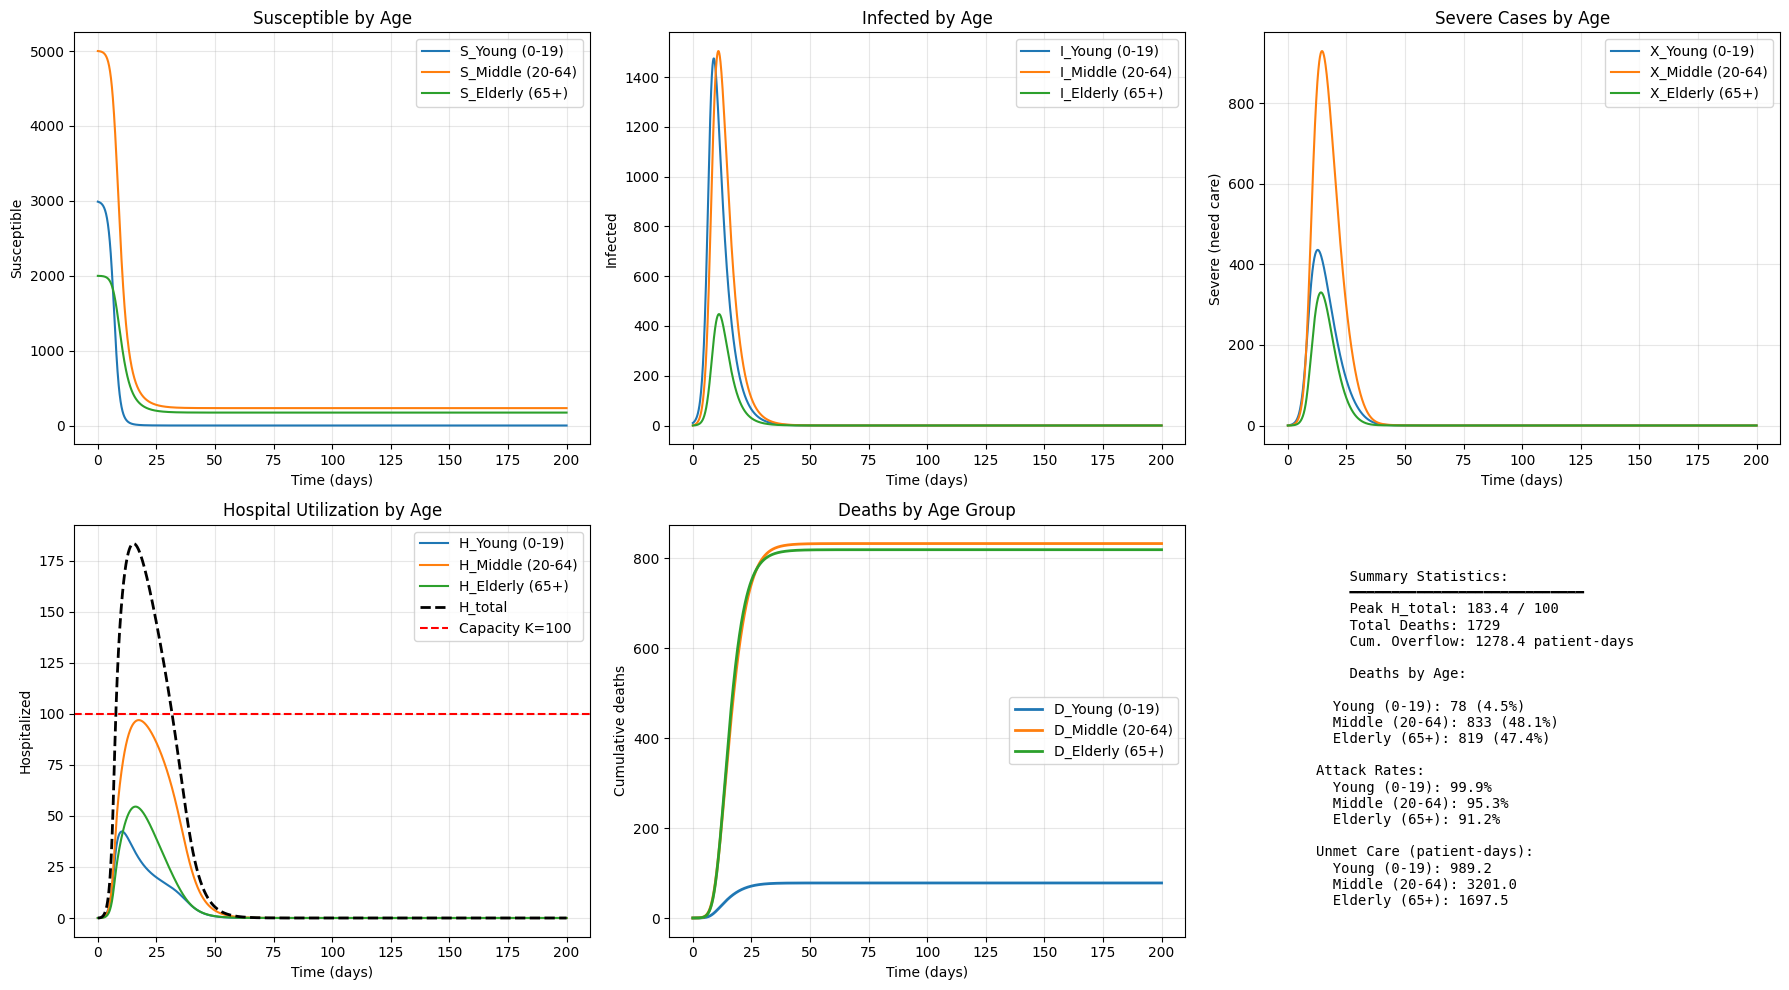


Age-Structured Model Results
Total deaths: 1729
Peak hospital occupancy: 183.4 (Capacity: 100)
Cumulative overflow: 1278.4 patient-days
  Young (0-19): 78 deaths, AR=99.9%
  Middle (20-64): 833 deaths, AR=95.3%
  Elderly (65+): 819 deaths, AR=91.2%


In [14]:
reduced_beta_results = simulate_age_structured_model(
    beta=0.1,  # Lower transmission
    age_params=age_params,
    contact_matrix=contact_matrix,
    hosp_capacity=100,
    hill_coef=4,
    coverage=coverage_by_age,
    VE=0.7,
    age_pops=age_pops,
    theta_X=0.5,
    theta_H=0.3,
    Tmax=200,
    time_step=0.1
)

plot_age_structured_results(reduced_beta_results, hosp_capacity=100, 
                           age_labels=['Young (0-19)', 'Middle (20-64)', 'Elderly (65+)'])

In [15]:
# Compare different vaccination strategies
strategies = {
    'No vaccination': [0.0, 0.0, 0.0],
    'Uniform 30%': [0.3, 0.3, 0.3],
    'Elderly priority': [0.1, 0.2, 0.7],
    'Young priority': [0.7, 0.2, 0.1],
    'Middle priority': [0.1, 0.7, 0.2]
}

strategy_results = {}

for strategy_name, coverage_by_age in strategies.items():
    reduced_beta_results = simulate_age_structured_model(
    beta=0.1,  # Lower transmission
    age_params=age_params,
    contact_matrix=contact_matrix,
    hosp_capacity=100,
    hill_coef=4,
    coverage=coverage_by_age,
    VE=0.7,
    age_pops=age_pops,
    theta_X=0.5,
    theta_H=0.3,
    Tmax=200,
    time_step=0.1
    )
    
    total_deaths = sum([reduced_beta_results['D'][a][-1] for a in range(3)])
    peak_H = max(reduced_beta_results['H_total'])
    
    strategy_results[strategy_name] = {
        'total_deaths': total_deaths,
        'deaths_by_age': [reduced_beta_results['D'][a][-1] for a in range(3)],
        'peak_H': peak_H,
        'cum_overflow': reduced_beta_results['cum_overflow'],
        'coverage': coverage_by_age
    }
    
    print(f"\n{strategy_name}:")
    print(f"  Coverage: Young={coverage_by_age[0]:.1f}, Middle={coverage_by_age[1]:.1f}, Elderly={coverage_by_age[2]:.1f}")
    print(f"  Total deaths: {total_deaths:.0f}")
    print(f"  Deaths by age: Young={reduced_beta_results['D'][0][-1]:.0f}, Middle={reduced_beta_results['D'][1][-1]:.0f}, Elderly={reduced_beta_results['D'][2][-1]:.0f}")
    print(f"  Peak hospital: {peak_H:.1f}")
    print(f"  Cumulative overflow: {reduced_beta_results['cum_overflow']:.1f}")


No vaccination:
  Coverage: Young=0.0, Middle=0.0, Elderly=0.0
  Total deaths: 1816
  Deaths by age: Young=79, Middle=880, Elderly=857
  Peak hospital: 191.7
  Cumulative overflow: 1267.7

Uniform 30%:
  Coverage: Young=0.3, Middle=0.3, Elderly=0.3
  Total deaths: 1754
  Deaths by age: Young=78, Middle=870, Elderly=805
  Peak hospital: 187.2
  Cumulative overflow: 1276.4

Elderly priority:
  Coverage: Young=0.1, Middle=0.2, Elderly=0.7
  Total deaths: 1607
  Deaths by age: Young=78, Middle=871, Elderly=658
  Peak hospital: 184.6
  Cumulative overflow: 1234.7

Young priority:
  Coverage: Young=0.7, Middle=0.2, Elderly=0.1
  Total deaths: 1786
  Deaths by age: Young=76, Middle=871, Elderly=838
  Peak hospital: 186.5
  Cumulative overflow: 1294.6

Middle priority:
  Coverage: Young=0.1, Middle=0.7, Elderly=0.2
  Total deaths: 1729
  Deaths by age: Young=78, Middle=833, Elderly=819
  Peak hospital: 183.4
  Cumulative overflow: 1278.4


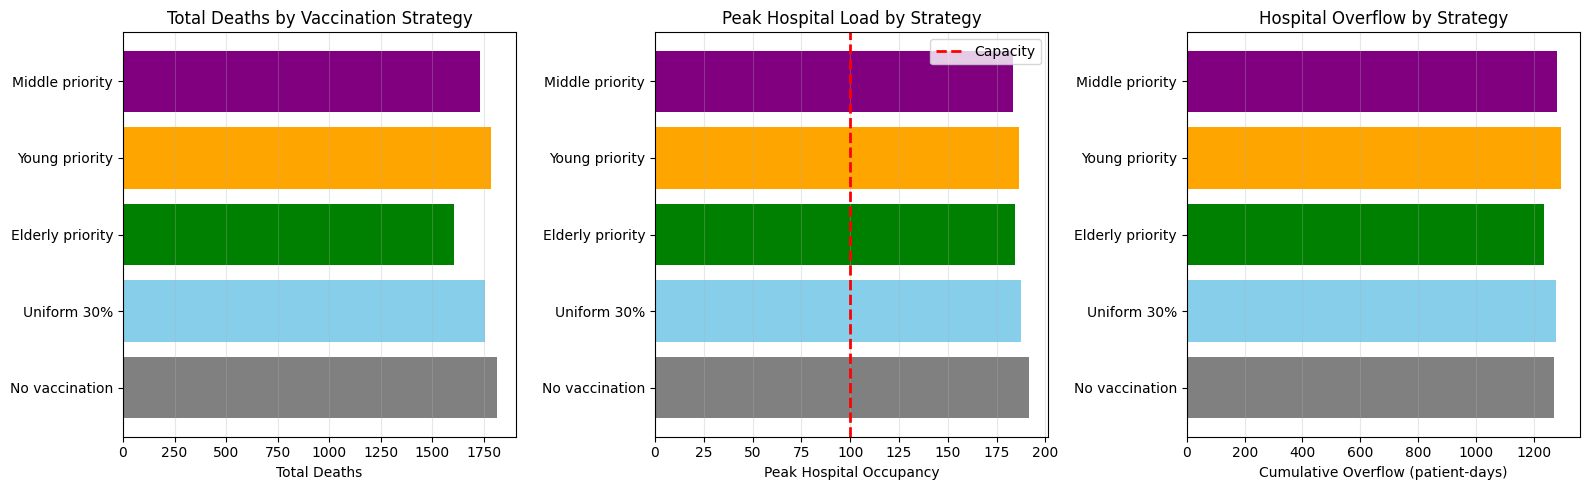

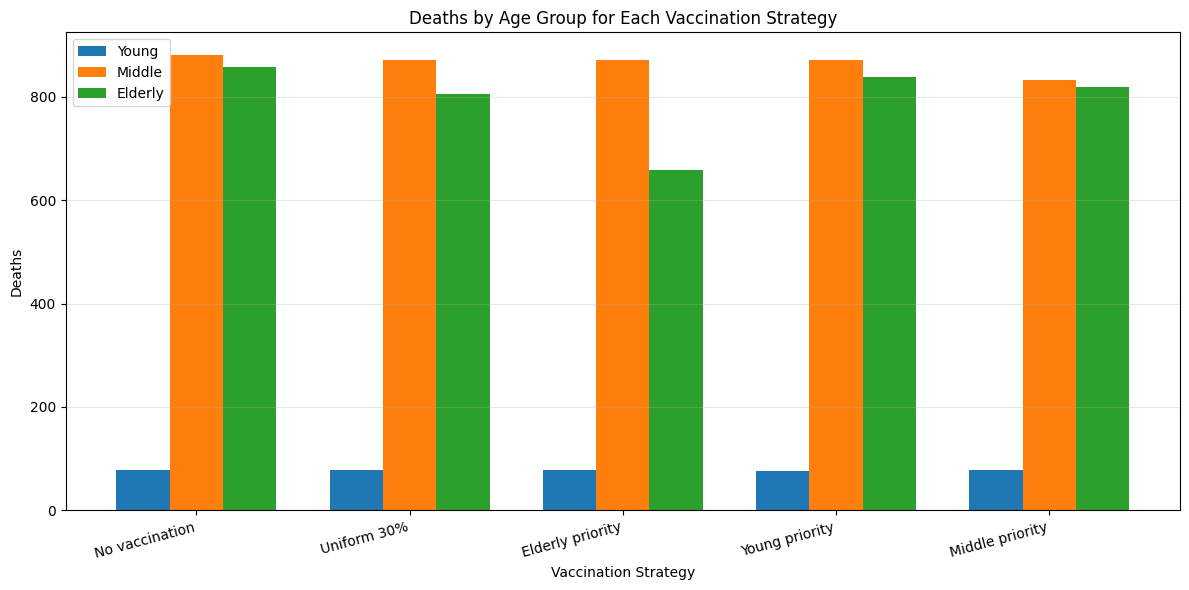

In [16]:
# Visualize vaccination strategy comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

strategies_list = list(strategy_results.keys())
total_deaths_list = [strategy_results[s]['total_deaths'] for s in strategies_list]
peak_H_list = [strategy_results[s]['peak_H'] for s in strategies_list]
overflow_list = [strategy_results[s]['cum_overflow'] for s in strategies_list]

# Total deaths comparison
axes[0].barh(strategies_list, total_deaths_list, color=['gray', 'skyblue', 'green', 'orange', 'purple'])
axes[0].set_xlabel('Total Deaths')
axes[0].set_title('Total Deaths by Vaccination Strategy')
axes[0].grid(True, alpha=0.3, axis='x')

# Peak hospital occupancy
axes[1].barh(strategies_list, peak_H_list, color=['gray', 'skyblue', 'green', 'orange', 'purple'])
axes[1].axvline(x=100, color='red', linestyle='--', label='Capacity', linewidth=2)
axes[1].set_xlabel('Peak Hospital Occupancy')
axes[1].set_title('Peak Hospital Load by Strategy')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Cumulative overflow
axes[2].barh(strategies_list, overflow_list, color=['gray', 'skyblue', 'green', 'orange', 'purple'])
axes[2].set_xlabel('Cumulative Overflow (patient-days)')
axes[2].set_title('Hospital Overflow by Strategy')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Deaths by age group for each strategy
fig, ax = plt.subplots(figsize=(12, 6))
age_labels = ['Young', 'Middle', 'Elderly']
x = np.arange(len(strategies_list))
width = 0.25

for i, age in enumerate(age_labels):
    deaths = [strategy_results[s]['deaths_by_age'][i] for s in strategies_list]
    ax.bar(x + i*width, deaths, width, label=age)

ax.set_xlabel('Vaccination Strategy')
ax.set_ylabel('Deaths')
ax.set_title('Deaths by Age Group for Each Vaccination Strategy')
ax.set_xticks(x + width)
ax.set_xticklabels(strategies_list, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [17]:
# Grid search over allocation strategies with fixed total coverage
# Total vaccine doses = 30% of total population
# Explore how to allocate across age groups

total_coverage_target = 0.3  # 30% of total pop
total_pop = sum(age_pops)
total_doses = total_coverage_target * total_pop

# Generate allocation grid
# coverage_young = fraction of young vaccinated (0 to 1)
# coverage_middle = fraction of middle vaccinated (0 to 1)  
# coverage_elderly = determined by constraint

n_grid = 20
young_cov_range = np.linspace(0, 1, n_grid)
middle_cov_range = np.linspace(0, 1, n_grid)

deaths_allocation_grid = np.zeros((n_grid, n_grid))
overflow_allocation_grid = np.zeros((n_grid, n_grid))

print(f"Searching for optimal allocation of {total_doses:.0f} vaccine doses...")
print(f"(Equivalent to {total_coverage_target*100:.0f}% of total population)")

for i, cov_young in enumerate(young_cov_range):
    for j, cov_middle in enumerate(middle_cov_range):
        # Calculate elderly coverage from constraint
        doses_young = cov_young * age_pops[0]
        doses_middle = cov_middle * age_pops[1]
        doses_elderly = total_doses - doses_young - doses_middle
        
        # Check if feasible
        if doses_elderly < 0 or doses_elderly > age_pops[2]:
            deaths_allocation_grid[i, j] = np.nan
            overflow_allocation_grid[i, j] = np.nan
            continue
        
        cov_elderly = doses_elderly / age_pops[2]
        
        # Run simulation
        reduced_beta_results = simulate_age_structured_model(
            beta=0.1,  # Lower transmission
            age_params=age_params,
            contact_matrix=contact_matrix,
            hosp_capacity=100,
            hill_coef=4,
            coverage=[cov_young, cov_middle, cov_elderly],
            VE=0.7,
            age_pops=age_pops,
            theta_X=0.5,
            theta_H=0.3,
            Tmax=200,
            time_step=0.1
            )
        
        total_deaths = sum([reduced_beta_results['D'][a][-1] for a in range(3)])
        deaths_allocation_grid[i, j] = total_deaths
        overflow_allocation_grid[i, j] = reduced_beta_results['cum_overflow']
print("Search complete.")

Searching for optimal allocation of 3000 vaccine doses...
(Equivalent to 30% of total population)
Search complete.
Search complete.


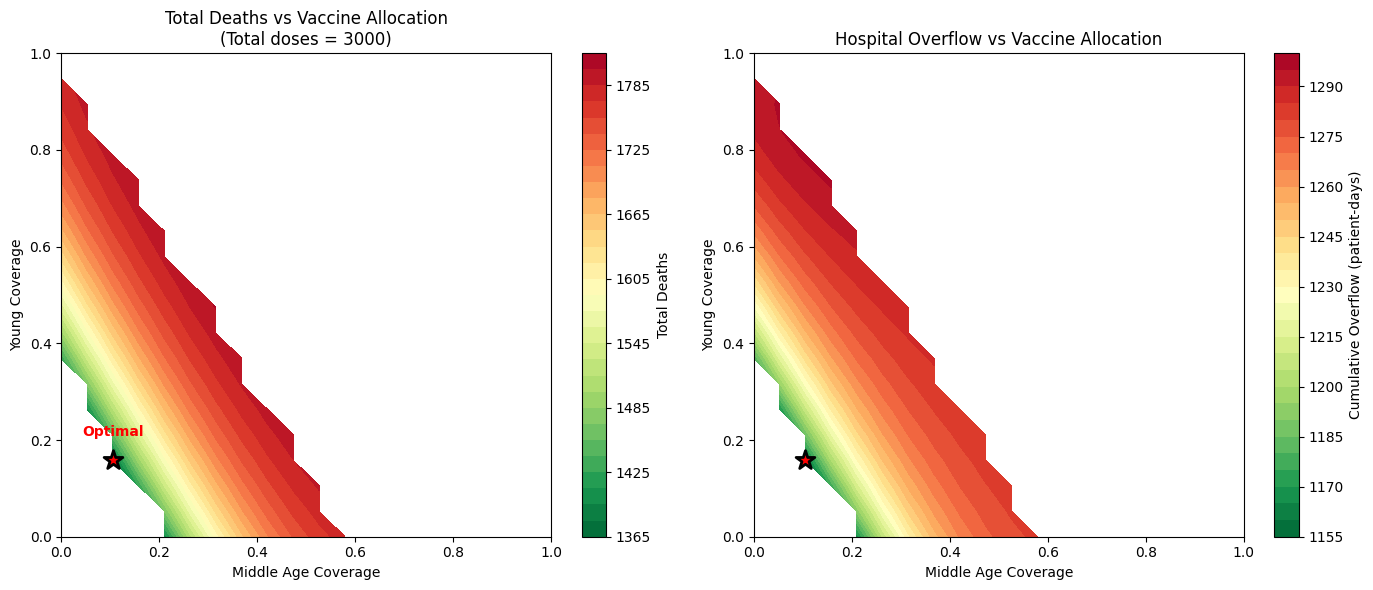


OPTIMAL ALLOCATION (Fixed total: 30% of population)
Young coverage: 15.8%
Middle coverage: 10.5%
Elderly coverage: 100.0%

Minimum deaths: 1378
Overflow at optimum: 1159.6 patient-days


In [18]:
# Visualize optimal allocation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Deaths heatmap
im1 = axes[0].contourf(middle_cov_range, young_cov_range, deaths_allocation_grid, 
                       levels=30, cmap='RdYlGn_r')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Total Deaths')

# Find and mark minimum
min_idx = np.nanargmin(deaths_allocation_grid)
min_i, min_j = np.unravel_index(min_idx, deaths_allocation_grid.shape)
opt_young = young_cov_range[min_i]
opt_middle = middle_cov_range[min_j]
opt_elderly = (total_doses - opt_young*age_pops[0] - opt_middle*age_pops[1]) / age_pops[2]

axes[0].scatter(opt_middle, opt_young, color='red', s=200, marker='*', 
               edgecolors='black', linewidths=2, zorder=10)
axes[0].text(opt_middle, opt_young + 0.05, 'Optimal', 
            ha='center', fontsize=10, weight='bold', color='red')

axes[0].set_xlabel('Middle Age Coverage')
axes[0].set_ylabel('Young Coverage')
axes[0].set_title(f'Total Deaths vs Vaccine Allocation\n(Total doses = {total_doses:.0f})')

# Overflow heatmap
im2 = axes[1].contourf(middle_cov_range, young_cov_range, overflow_allocation_grid, 
                       levels=30, cmap='RdYlGn_r')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Cumulative Overflow (patient-days)')

axes[1].scatter(opt_middle, opt_young, color='red', s=200, marker='*', 
               edgecolors='black', linewidths=2, zorder=10)
axes[1].set_xlabel('Middle Age Coverage')
axes[1].set_ylabel('Young Coverage')
axes[1].set_title('Hospital Overflow vs Vaccine Allocation')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"OPTIMAL ALLOCATION (Fixed total: {total_coverage_target*100:.0f}% of population)")
print(f"{'='*60}")
print(f"Young coverage: {opt_young*100:.1f}%")
print(f"Middle coverage: {opt_middle*100:.1f}%")
print(f"Elderly coverage: {opt_elderly*100:.1f}%")
print(f"\nMinimum deaths: {np.nanmin(deaths_allocation_grid):.0f}")
print(f"Overflow at optimum: {overflow_allocation_grid[min_i, min_j]:.1f} patient-days")

# Using the Refactored Modular Code

The code has been reorganized for better maintainability and reusability:

- **`config.py`**: Centralized parameters, age-specific disease params, contact matrices, vaccination strategies
- **`hospital_models.py`**: Core simulation functions with comprehensive docstrings
- **`simulation_helpers.py`**: Reusable functions for strategy comparison and optimization
- **`plotting_utils.py`**: All visualization functions

This eliminates code duplication and follows SOLID/DRY principles.

In [24]:
# example: using centralized config parameters
import config

print("Default simulation parameters:")
for key, value in config.DEFAULT_SIM_PARAMS.items():
    print(f"  {key}: {value}")

print(f"\nAge groups: {config.AGE_LABELS}")
print(f"Default populations: {config.AGE_POPS_DEFAULT}")
print(f"\nContact matrix:\n{config.CONTACT_MATRIX_DEFAULT}")

Default simulation parameters:
  Tmax: 200
  time_step: 0.1
  hill_coef: 4
  theta_X: 0.5
  theta_H: 0.3
  VE: 0.7

Age groups: ['Young (0-19)', 'Middle (20-64)', 'Elderly (65+)']
Default populations: [3000, 5000, 2000]

Contact matrix:
[[10.  3.  1.]
 [ 3.  8.  2.]
 [ 1.  2.  4.]]


## Example: Compare Vaccination Strategies (Refactored)

Using the new `compare_vaccination_strategies()` function instead of duplicated loops.


No vaccination:
  Coverage: Young=0.0, Middle=0.0, Elderly=0.0
  Total deaths: 1816
  Deaths by age: Young=79, Middle=880, Elderly=857
  Peak hospital: 191.7
  Cumulative overflow: 1267.7

Uniform 30%:
  Coverage: Young=0.3, Middle=0.3, Elderly=0.3
  Total deaths: 1754
  Deaths by age: Young=78, Middle=870, Elderly=805
  Peak hospital: 187.2
  Cumulative overflow: 1276.4

Elderly priority:
  Coverage: Young=0.1, Middle=0.2, Elderly=0.7
  Total deaths: 1607
  Deaths by age: Young=78, Middle=871, Elderly=658
  Peak hospital: 184.6
  Cumulative overflow: 1234.7

Young priority:
  Coverage: Young=0.7, Middle=0.2, Elderly=0.1
  Total deaths: 1786
  Deaths by age: Young=76, Middle=871, Elderly=838
  Peak hospital: 186.5
  Cumulative overflow: 1294.6

Middle priority:
  Coverage: Young=0.1, Middle=0.7, Elderly=0.2
  Total deaths: 1729
  Deaths by age: Young=78, Middle=833, Elderly=819
  Peak hospital: 183.4
  Cumulative overflow: 1278.4


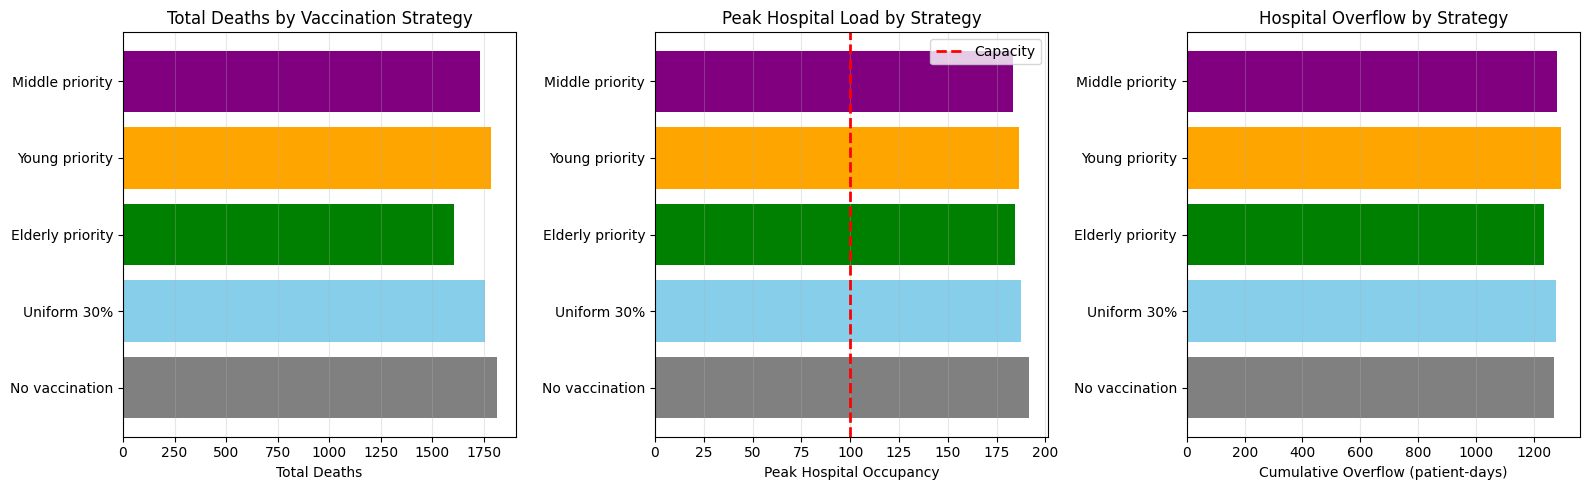

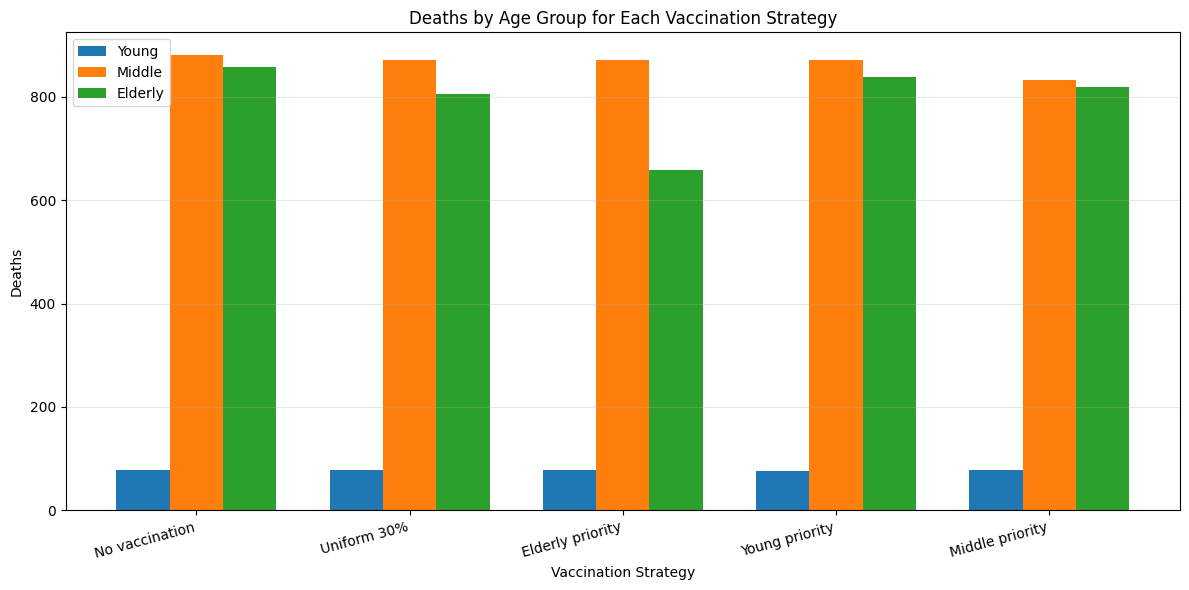

In [1]:
# import helper functions
from simulation_helpers import compare_vaccination_strategies
from plotting_utils import plot_strategy_comparison
import config

# run comparison using config defaults
strategy_results = compare_vaccination_strategies(
    beta=0.1,
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    hosp_capacity=100,
    age_pops=config.AGE_POPS_DEFAULT,
    strategies=config.VACCINATION_STRATEGIES,
    hill_coef=config.DEFAULT_SIM_PARAMS['hill_coef'],
    VE=config.DEFAULT_SIM_PARAMS['VE'],
    theta_X=config.DEFAULT_SIM_PARAMS['theta_X'],
    theta_H=config.DEFAULT_SIM_PARAMS['theta_H'],
    Tmax=config.DEFAULT_SIM_PARAMS['Tmax'],
    time_step=config.DEFAULT_SIM_PARAMS['time_step']
)

# visualize results
plot_strategy_comparison(strategy_results, hosp_capacity=100, 
                        age_labels=config.AGE_LABELS_SHORT)

## Example: Optimize Vaccine Allocation (Refactored)

Using the new `optimize_vaccine_allocation()` and `plot_optimal_allocation()` functions.

Searching for optimal allocation of 600000 vaccine doses...
(Equivalent to 30% of total population)
Search complete.
Search complete.


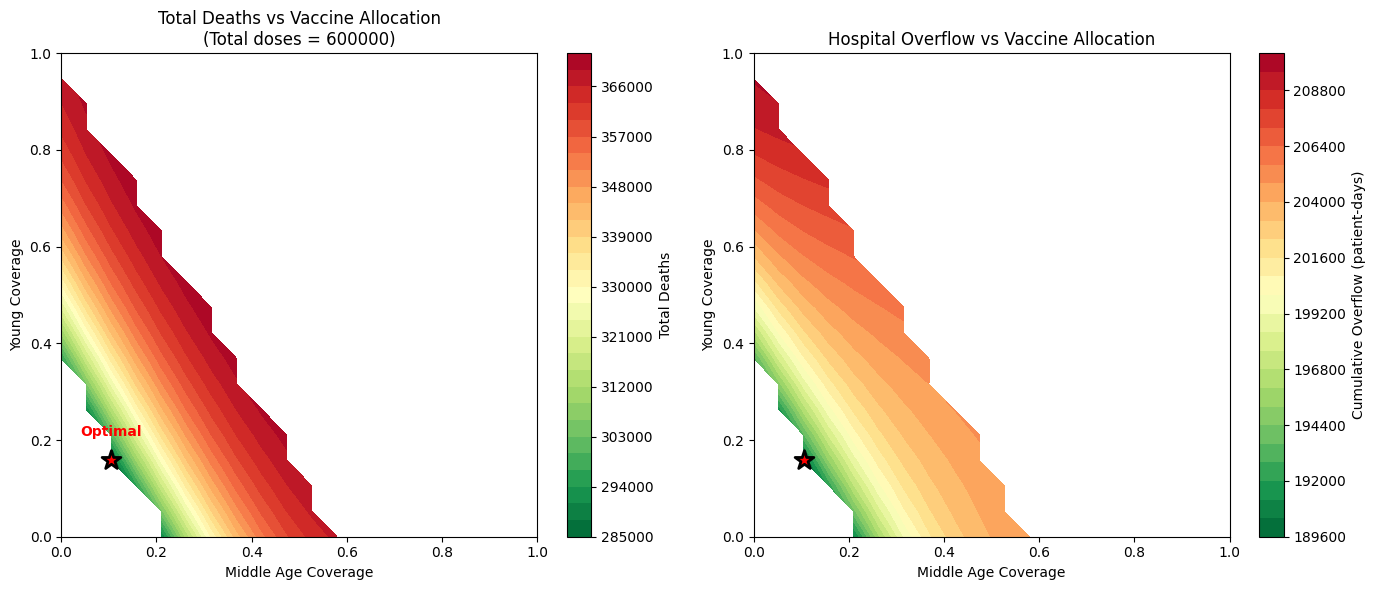


OPTIMAL ALLOCATION (Fixed total: 600000 doses)
Young coverage: 15.8%
Middle coverage: 10.5%
Elderly coverage: 100.0%

Minimum deaths: 286132
Overflow at optimum: 190027.7 patient-days


In [32]:
# import helper functions
from simulation_helpers import optimize_vaccine_allocation
from plotting_utils import plot_optimal_allocation
import config

# run optimization
deaths_grid, overflow_grid, young_range, middle_range = optimize_vaccine_allocation(
    beta=0.1,
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    hosp_capacity=10000,
    age_pops=config.AGE_POPS_LARGE_DEFAULT,
    total_coverage_target=0.3,
    n_grid=20,
    hill_coef=config.DEFAULT_SIM_PARAMS['hill_coef'],
    VE=config.DEFAULT_SIM_PARAMS['VE']
)

# visualize and get optimal allocation
total_pop = sum(config.AGE_POPS_LARGE_DEFAULT)
total_doses = 0.3 * total_pop

opt_young, opt_middle, opt_elderly = plot_optimal_allocation(
    deaths_grid, overflow_grid, young_range, middle_range,
    age_pops=config.AGE_POPS_LARGE_DEFAULT,
    total_doses=total_doses
)

## Example: Test Alternative Contact Matrices

The config module provides multiple contact matrix options for experimentation.

In [ ]:
# compare outcomes under different mixing patterns
from hospital_models import simulate_age_structured_model
import config

contact_scenarios = {
    'Default (assortative)': config.CONTACT_MATRIX_DEFAULT,
    'Homogeneous': config.CONTACT_MATRIX_HOMOGENEOUS,
    'Strong assortative': config.CONTACT_MATRIX_ASSORTATIVE
}

print("Comparing contact matrix scenarios with elderly priority vaccination:")
print("="*70)

for scenario_name, contact_matrix in contact_scenarios.items():
    results = simulate_age_structured_model(
        beta=0.3,
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=contact_matrix,
        hosp_capacity=100,
        hill_coef=4,
        coverage=[0.1, 0.2, 0.7],  # elderly priority
        VE=0.7,
        age_pops=config.AGE_POPS_LARGE_DEFAULT
    )
    
    total_deaths = sum([results['D'][a][-1] for a in range(3)])
    peak_H = max(results['H_total'])
    
    print(f"\n{scenario_name}:")
    print(f"  Total deaths: {total_deaths:.0f}")
    print(f"  Peak hospital: {peak_H:.1f}")
    print(f"  Deaths by age: Young={results['D'][0][-1]:.0f}, "
          f"Middle={results['D'][1][-1]:.0f}, Elderly={results['D'][2][-1]:.0f}")

Comparing contact matrix scenarios with elderly priority vaccination:

Default (assortative):
  Total deaths: 294956
  Peak hospital: 261162.7
  Deaths by age: Young=12410, Middle=132011, Elderly=150535

Homogeneous:
  Total deaths: 296848
  Peak hospital: 268224.9
  Deaths by age: Young=12411, Middle=132019, Elderly=152417

Strong assortative:
  Total deaths: 294914
  Peak hospital: 260379.8
  Deaths by age: Young=12410, Middle=132009, Elderly=150495


# Time-Varying SIXHRD Model

Time-varying extensions include:
- **Seasonal transmission**: $\beta(t) = \beta_0 \cdot (1 + A \cos(2\pi t / T))$
- **Policy interventions**: Step functions for lockdowns/relaxations
- **Waning immunity**: Flow from R → S at rate $\omega$

These features allow modeling of:
- Multiple epidemic waves
- Effects of seasonal respiratory virus patterns
- Impact of lockdown timing and duration
- Long-term dynamics with immunity loss

## Example 1: Seasonal Transmission

Model respiratory virus seasonality with winter transmission peaks.

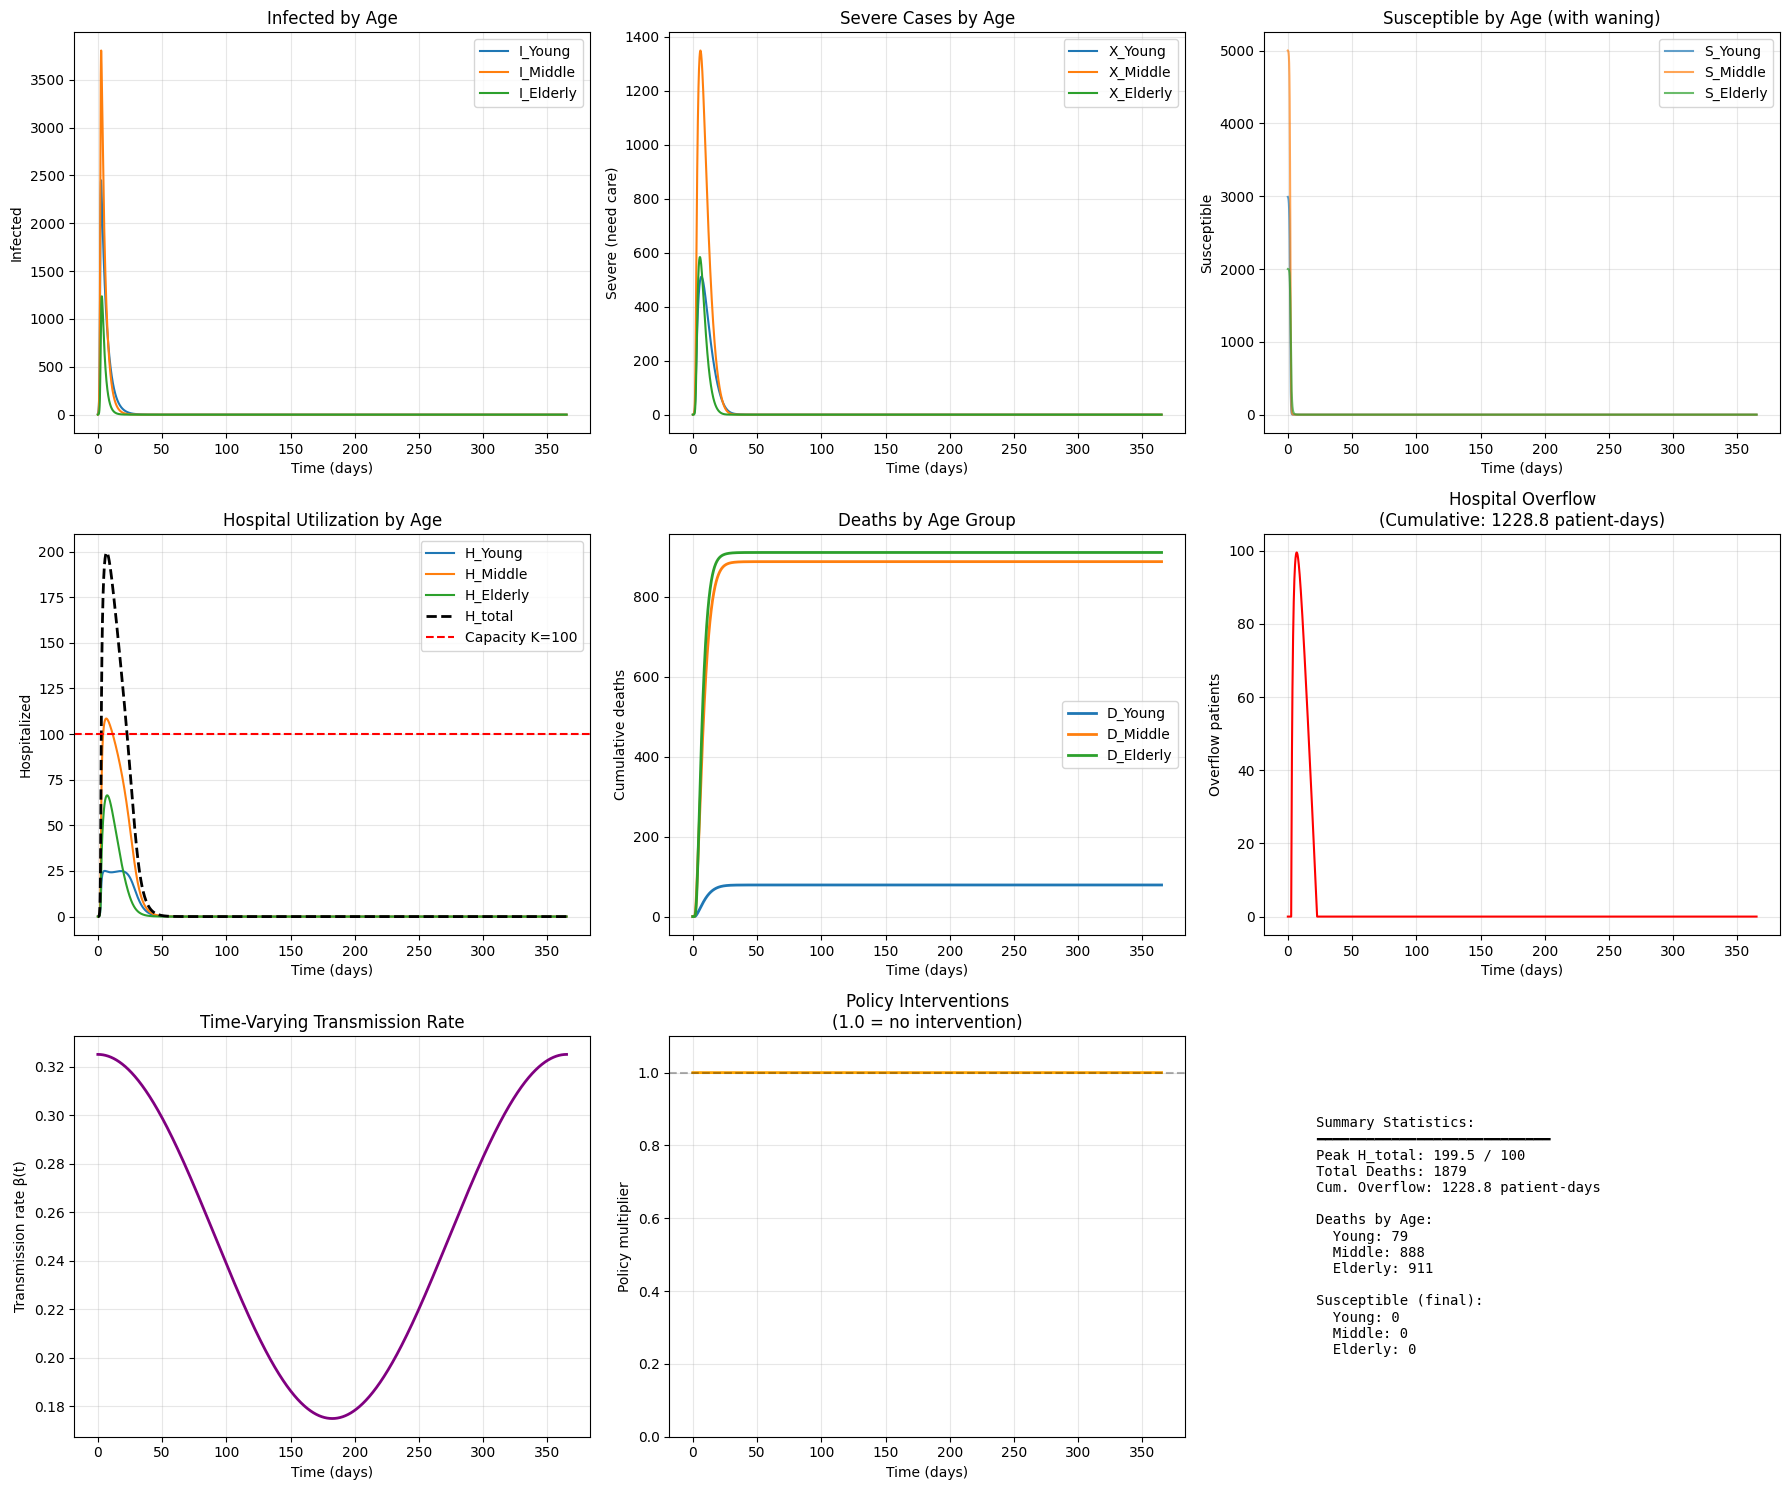


Time-Varying Model Results
Total deaths: 1879
Peak hospital occupancy: 199.5 (Capacity: 100)
Cumulative overflow: 1228.8 patient-days
Beta range: [0.175, 0.325]


In [ ]:
from time_varying_models import simulate_age_structured_time_varying
from plotting_utils import plot_time_varying_results
import config

# simulate seasonal transmission over 1 year
results_seasonal = simulate_age_structured_time_varying(
    beta_base=0.25,  # baseline transmission
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    hosp_capacity=100,
    hill_coef=4,
    coverage=0.0,  # no vaccination
    VE=0.7,
    age_pops=config.AGE_POPS_DEFAULT,
    seasonal_params=config.SEASONAL_PARAMS,
    waning_params=None,  # no waning
    interventions=None,  # no interventions
    Tmax=365  # simulate full year
)

plot_time_varying_results(results_seasonal, hosp_capacity=100,
                          age_labels=config.AGE_LABELS_SHORT)

## Example 2: Policy Interventions (Lockdown)

Model a 50-day lockdown reducing transmission by 60%.

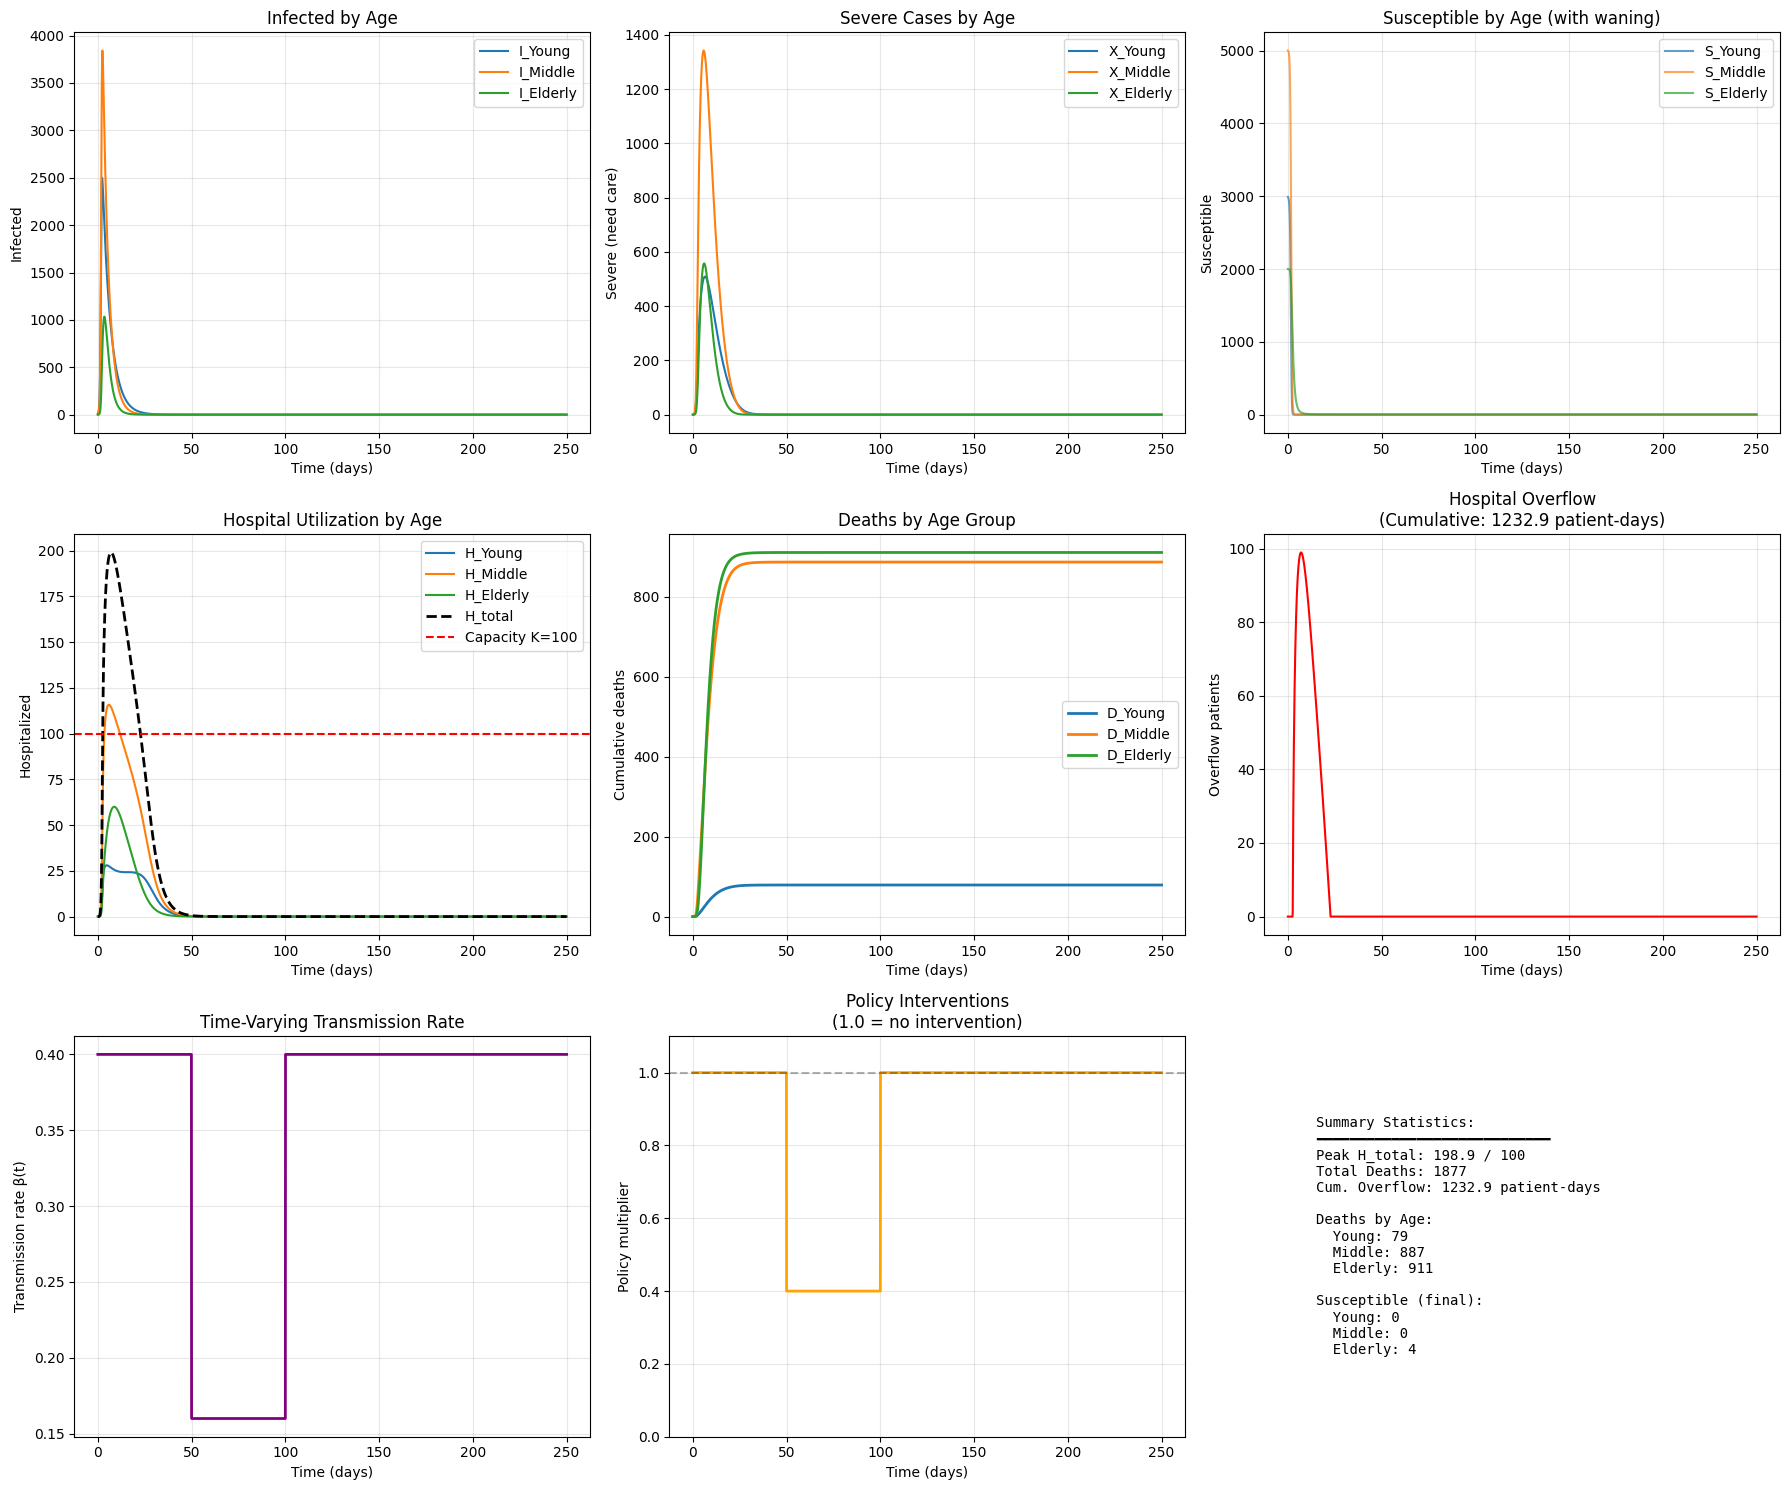


Time-Varying Model Results
Total deaths: 1877
Peak hospital occupancy: 198.9 (Capacity: 100)
Cumulative overflow: 1232.9 patient-days
Beta range: [0.160, 0.400]


In [5]:
# default lockdown scenario: 50-day intervention starting at day 50

results_lockdown = simulate_age_structured_time_varying(
    beta_base=0.4,  # higher baseline (requires intervention)
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    hosp_capacity=100,
    hill_coef=4,
    coverage=[0.1, 0.2, 0.7],  # elderly priority vaccination
    VE=0.7,
    age_pops=config.AGE_POPS_DEFAULT,
    seasonal_params=None,  # no seasonality
    waning_params=None,  # no waning
    interventions=config.LOCKDOWN_SCENARIO,
    Tmax=250
)

plot_time_varying_results(results_lockdown, hosp_capacity=100,
                          age_labels=config.AGE_LABELS_SHORT)

## Example 3: Waning Immunity

Model immunity loss with flow from R → S, allowing reinfection.

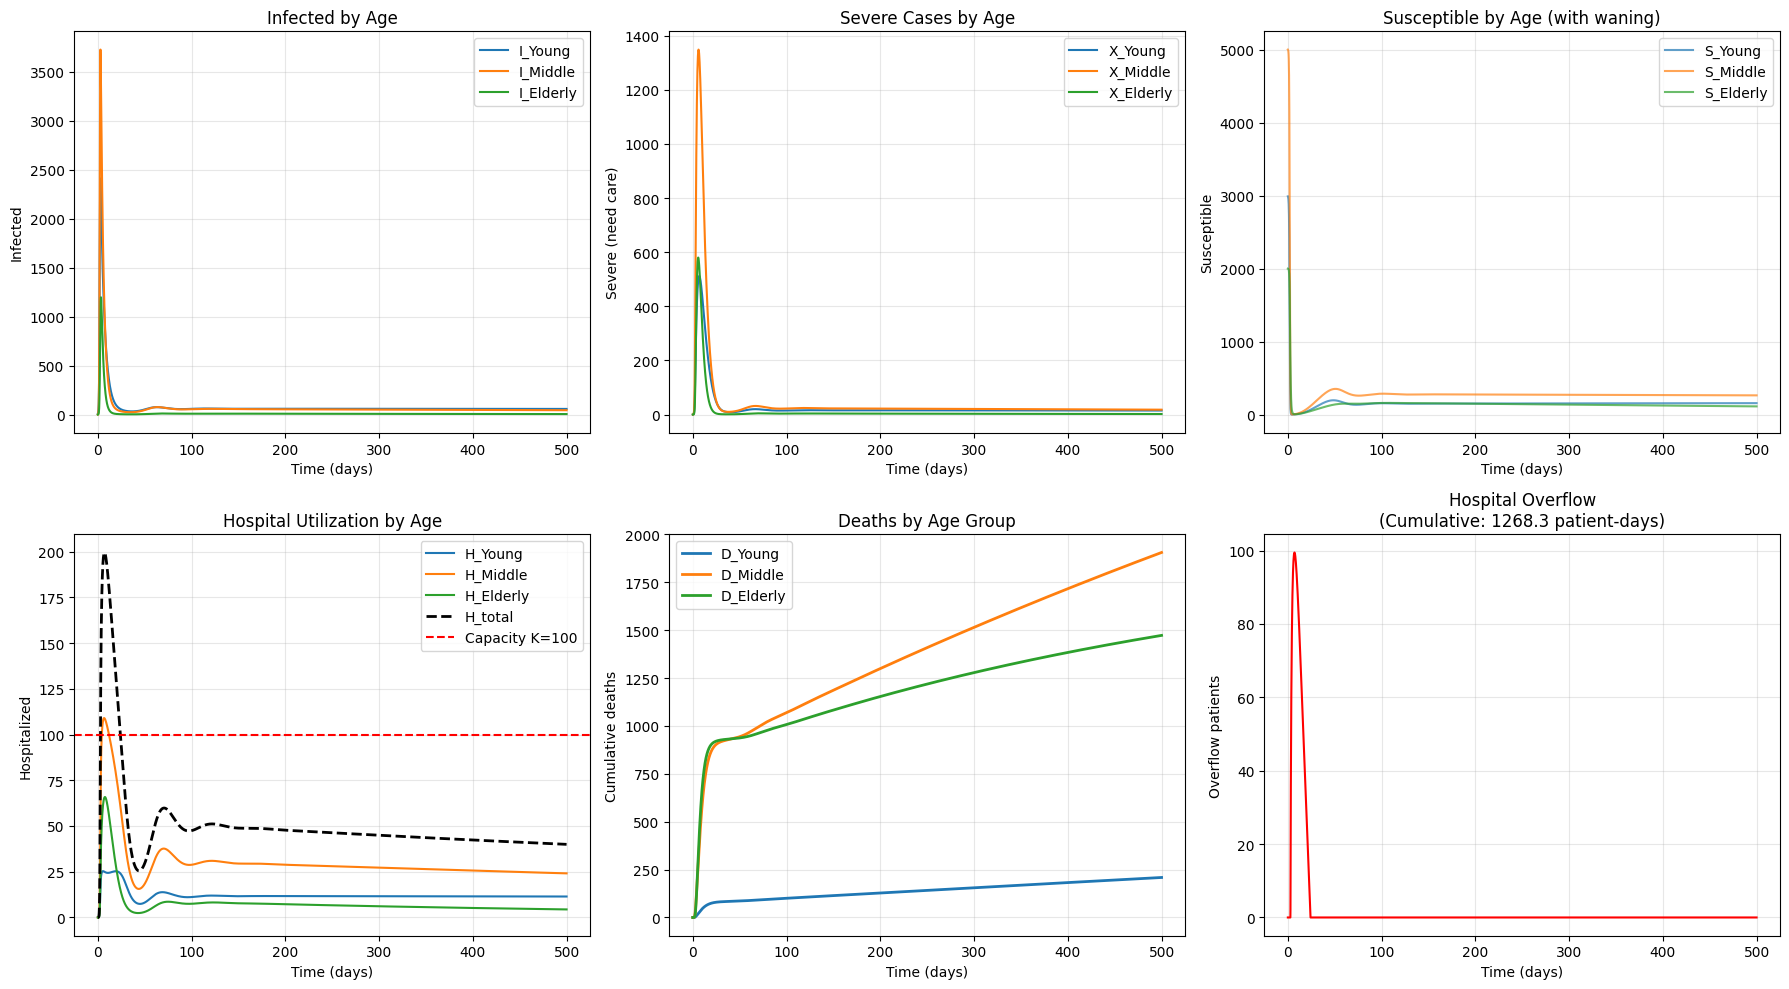


Time-Varying Model Results
Total deaths: 3587
Peak hospital occupancy: 199.5 (Capacity: 100)
Cumulative overflow: 1268.3 patient-days
Beta range: [0.300, 0.300]


In [3]:
# waning immunity: average immunity lasts 200 days (omega = 1/200 = 0.005)
waning_params = {
    'omega': 0.005  # uniform waning rate across all ages
}

results_waning = simulate_age_structured_time_varying(
    beta_base=0.3,
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    hosp_capacity=100,
    hill_coef=4,
    coverage=0.0,  # no vaccination
    VE=0.7,
    age_pops=config.AGE_POPS_DEFAULT,
    seasonal_params=None,
    waning_params=waning_params,
    interventions=None,
    Tmax=500  # longer simulation to see waning effects
)

plot_time_varying_results(results_waning, hosp_capacity=100,
                          age_labels=config.AGE_LABELS_SHORT,
                          show_beta=False, show_policy=False)

## Example 4: Combined Scenario (Realistic Epidemic)

Combine all three features: seasonality + lockdowns + waning immunity.

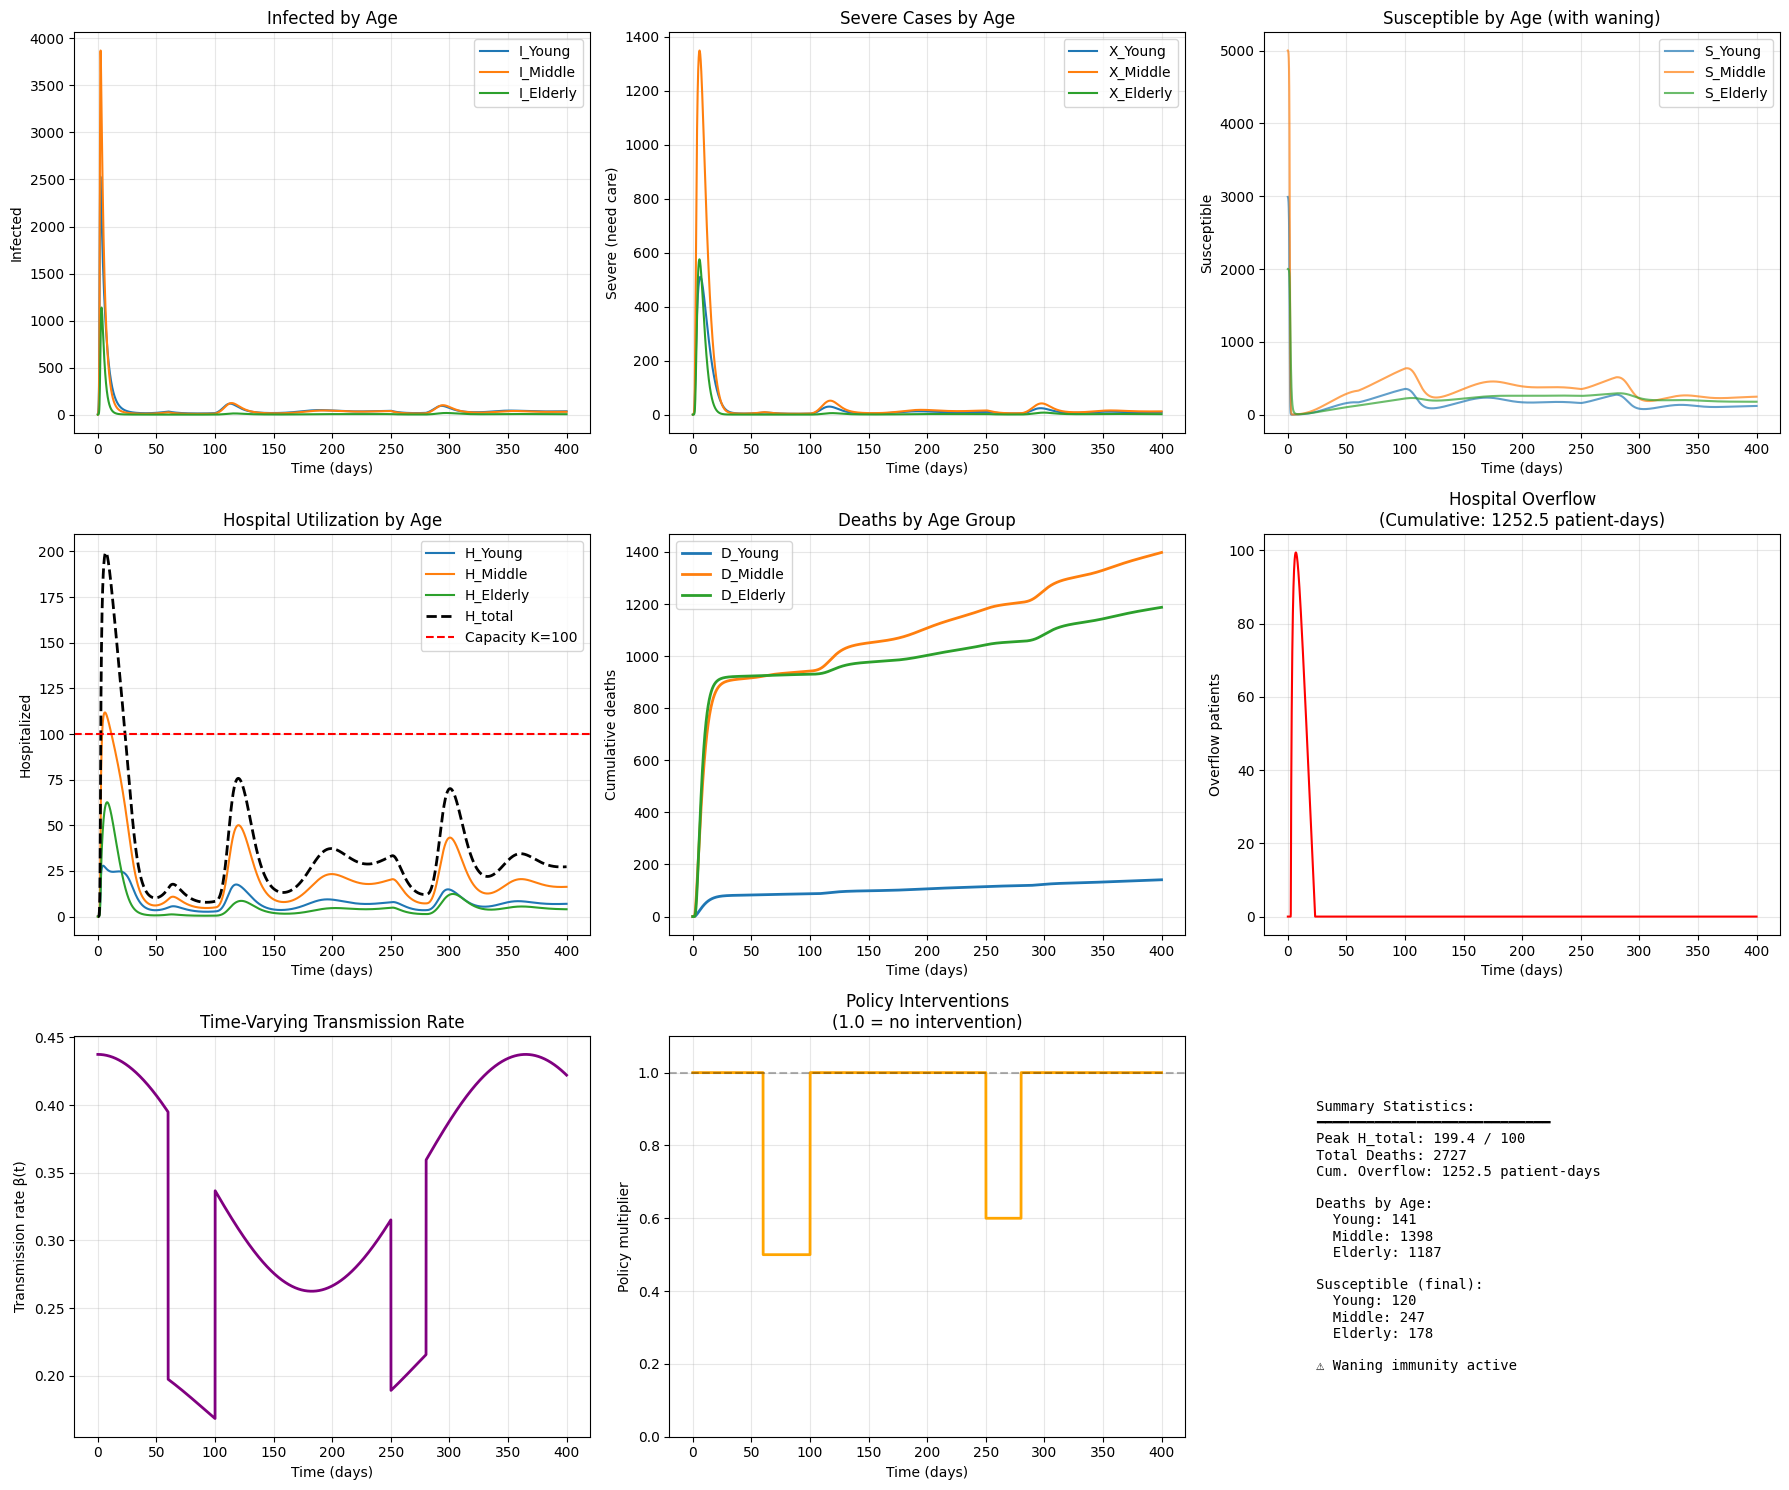


Time-Varying Model Results
Total deaths: 2727
Peak hospital occupancy: 199.4 (Capacity: 100)
Cumulative overflow: 1252.5 patient-days
Beta range: [0.168, 0.438]

Multiple waves with seasonal forcing and waning immunity:
Notice how seasonality + waning can create multiple epidemic peaks


In [4]:
# combined scenario: seasonality + two lockdowns + waning immunity
seasonal_params_combined = {
    'amplitude': 0.25,
    'period': 365,
    'peak_day': 0
}

multiple_lockdowns = [
    {'start_day': 60, 'end_day': 100, 'transmission_reduction': 0.5},   # first wave response
    {'start_day': 250, 'end_day': 280, 'transmission_reduction': 0.4}   # second wave response
]

waning_params_combined = {
    'omega': 0.003  # immunity lasts ~333 days on average
}

results_combined = simulate_age_structured_time_varying(
    beta_base=0.35,
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    hosp_capacity=100,
    hill_coef=4,
    coverage=[0.1, 0.3, 0.6],  # progressive vaccination
    VE=0.7,
    age_pops=config.AGE_POPS_DEFAULT,
    seasonal_params=seasonal_params_combined,
    waning_params=waning_params_combined,
    interventions=multiple_lockdowns,
    Tmax=400
)

plot_time_varying_results(results_combined, hosp_capacity=100,
                          age_labels=config.AGE_LABELS_SHORT)

print("\nMultiple waves with seasonal forcing and waning immunity:")
print("Notice how seasonality + waning can create multiple epidemic peaks")